# 09 — CG Governance Index -> Financial Outcomes (Forward-Looking Panel)

Rewrite of the original contemporaneous-timing regression notebook (preserved as
`09_regression_v1_contemporaneous.ipynb`). **Timing convention throughout: `CG_t -> outcome_{t+1}`.**
`CG_t` is firm i's composite (or sub-index) score for fiscal year t, averaged across that
FY's four quarters. Every outcome is measured *after* `CG_t` becomes public — either a
252-trading-day forward window starting at `max(Filing_Date)` across FY t's filings + 2
trading days (returns/alpha/vol), or FY(t+1) itself (ROE). No outcome is measured over a
window that overlaps the period used to construct `CG_t`.

**Panel is T=2 (FY23, FY24), determined empirically, not assumed.** `CG_t` needs FY t
candidates FY22-FY25; checking each against `ff5mom_factors_monthly.csv` (2022-07 to
2026-04) and `annual_roe.csv` (FY23-FY25 only) coverage:
- **FY22**: observable date (~May-Oct 2022) sits right at/before the start of factor
  coverage -> only 5/329 firms have a fully-covered 252-day outcome window. Dropped.
- **FY23**: fully covered -> 389/389 firms.
- **FY24**: fully covered -> 426/426 firms.
- **FY25**: observable date (~mid-2025) + 252 trading days runs past the factor data's
  2026-04 end for nearly every firm (8/470 covered), and `roe_{t+1}` would need FY26 ROE,
  which doesn't exist in `annual_roe.csv`. Dropped.

This lines up exactly with the framing decision's "no firm FE (T=2 only)" — confirmed by
the data, not asserted.

**LHS (outcomes, all `_{t+1}`)**: `mar_pct`, `capm_alpha` (vs. Nifty 500), `ff5_alpha`
(vs. FF5+MOM, computed directly here — the unrun cell in `08_ff5_regression.ipynb`
estimates a pooled panel coefficient, not per-firm alphas, so it isn't a usable source for
this per-firm LHS variable), `total_vol`, `idio_vol`, `downside_vol`, `roe`.

**RHS**: `CG_t`, Van der Waerden-normalised within its FY cross-section, per sub-index and
for the composite (mean of the six). Controls (`Beta_Market`, `Momentum`, `Log_MarketCap`,
`DE_Ratio`) measured at Q4 of FY t — the same reference point as `CG_t` itself, not
contemporaneous with the LHS.

**Fixed effects**: industry + year (FY23/FY24 dummy). No firm FE — T=2 gives at most one
within-firm difference per firm, too thin to identify reliably.

**SE**: firm-clustered (HC3 fallback), matching the rest of this project.

**Specifications reported**: individual sub-index (six separate models per outcome), joint
(all six simultaneously), and composite (mean, as a summary specification) — **no PC1
regression**, per `07_index_validation.ipynb` §3.3's finding that PC1 is a compositional
contrast, not a governance-quality level.

**Multiple testing**: Romano-Wolf step-down (cluster/firm bootstrap, B=2,000) across the
6 sub-indices x 7 outcomes = 42-test family.

**Robustness**: balanced panel (firms present in both FY23 and FY24).

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import statsmodels.api as sm
import yfinance as yf
import yf_cache
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import norm
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

BASE = Path.cwd()
PROC = BASE / 'data' / 'processed'
RAW  = BASE / 'data' / 'raw'

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)

CG_CATS = ['AINDEX', 'BINDEX', 'CINDEX', 'DINDEX', 'OINDEX', 'TRINDEX']
CTRL    = ['Beta_Market', 'Momentum', 'Log_MarketCap', 'DE_Ratio']
OUTCOMES = ['mar_pct', 'capm_alpha', 'ff5_alpha', 'total_vol', 'idio_vol', 'downside_vol', 'roe']
FACTOR_COLS = ['Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']
RF_ANNUAL, RF_DAILY = 0.065, 0.065 / 252
FWD_WIN, MIN_OBS = 252, 200
RW_B = 2000

print(f'Outcomes: {OUTCOMES}')
print(f'Forward window: {FWD_WIN} trading days, min {MIN_OBS} obs required')

Outcomes: ['mar_pct', 'capm_alpha', 'ff5_alpha', 'total_vol', 'idio_vol', 'downside_vol', 'roe']
Forward window: 252 trading days, min 200 obs required


## 1 — Forward-looking outcome construction

Daily prices (matched universe), Nifty 500 (`^CRSLDX`, the CAPM benchmark — same choice as
`03_targets.ipynb`), and daily FF5+MOM factors (reconstructed from monthly, same method as
`08`/`10`/`11`). For each firm-FY, the outcome window starts at `max(Filing_Date)` across
that FY's filings + 2 trading days and runs forward 252 trading days.

In [2]:
imap = pd.read_excel(PROC / 'industry_map.xlsx')[['BSE Code', 'NSE Symbol', 'Industry']].dropna(subset=['NSE Symbol'])
imap['BSE Code'] = pd.to_numeric(imap['BSE Code'], errors='coerce')
tickers_ns = [f'{s}.NS' for s in imap['NSE Symbol']]

today = pd.Timestamp.today().normalize()
px_raw = yf_cache.download(tickers_ns, start='2019-07-01', end=(today + pd.Timedelta(days=1)).strftime('%Y-%m-%d'),
                     auto_adjust=True, progress=True)['Close']
valid = px_raw.columns[px_raw.isna().mean() < 0.5].tolist()
px = px_raw[valid]
ret_d = np.log(px / px.shift(1)).dropna(how='all')

nifty_raw = yf_cache.download('^CRSLDX', start='2019-07-01', end=(today + pd.Timedelta(days=1)).strftime('%Y-%m-%d'),
                        auto_adjust=True, progress=False)['Close'].squeeze()
nifty_ret = np.log(nifty_raw / nifty_raw.shift(1)).dropna()
nifty_ret.name = 'market'

print(f'Valid tickers: {len(valid)} / {len(tickers_ns)}  (through {px.index.max().date()})')
print(f'Nifty 500: {len(nifty_ret)} trading days')

[                       0%                       ]

[                       1%                       ]  2 of 247 completed

[                       1%                       ]  3 of 247 completed

[*                      2%                       ]  4 of 247 completed

[*                      2%                       ]  5 of 247 completed

...



8 Failed downloads:


['GET&D.NS', 'ZOMATO.NS', 'PEL.NS', 'SUVENPHARMA.NS', 'ISEC.NS']: possibly delisted; no timezone found


['HINDCOPPER.NS', 'JINDALSTEL.NS']: TypeError("'NoneType' object is not subscriptable")


['AKZOINDIA.NS']: possibly delisted; no price data found  (1d 2019-07-01 -> 2026-07-22) (Yahoo error = "No data found, symbol may be delisted")


Valid tickers: 237 / 247  (through 2026-07-21)
Nifty 500: 1734 trading days


In [3]:
factors_m = pd.read_csv(PROC / 'ff5mom_factors_monthly.csv', parse_dates=['Date']).set_index('Date')
fac_m = factors_m.copy()
fac_m.index = fac_m.index.year * 100 + fac_m.index.month
daily_key = ret_d.index.year * 100 + ret_d.index.month
td_per_month = pd.Series(1, index=daily_key).groupby(level=0).sum()
fac_for_day = fac_m.reindex(daily_key)
td_for_day = td_per_month.reindex(daily_key).fillna(21).values
factors_d = pd.DataFrame(fac_for_day.values / td_for_day[:, None], index=ret_d.index, columns=FACTOR_COLS)
factors_d['CMA'] = factors_d['CMA'].fillna(0)
print(f'Factor coverage: {factors_m.index.min().date()} -> {factors_m.index.max().date()}')

trading_days = ret_d.index

fdb = pd.read_csv(PROC / 'filing_dates_db.csv')
fdb['BSE_Code'] = pd.to_numeric(fdb['BSE_Code'], errors='coerce')
fdb['Filing_Date'] = pd.to_datetime(fdb['Filing_Date'])


def observable_dates_for_fy(fy):
    quarters = [f'Q{q}{fy}' for q in range(1, 5)]
    sub = fdb[fdb['Q_FY'].isin(quarters)]
    obs = sub.groupby('BSE_Code')['Filing_Date'].max().reset_index()
    return (obs.merge(imap, left_on='BSE_Code', right_on='BSE Code', how='left')
               .dropna(subset=['NSE Symbol']))


def compute_outcome(ticker, obs_date):
    """252-td forward window starting 2 trading days after obs_date. Returns None if the
    ticker is missing or the window isn't fully covered by price/factor data."""
    if ticker not in ret_d.columns:
        return None
    pos0 = trading_days.searchsorted(obs_date)
    pos = pos0 + 2
    if pos + FWD_WIN > len(trading_days):
        return None
    window = trading_days[pos: pos + FWD_WIN]
    stk = ret_d.loc[window, ticker]
    mkt = nifty_ret.reindex(window)
    fac = factors_d.loc[window, FACTOR_COLS]
    aligned = pd.concat([stk.rename('stk'), mkt.rename('mkt'), fac], axis=1).dropna()
    if len(aligned) < MIN_OBS:
        return None

    stk_ex = aligned['stk'] - RF_DAILY
    mkt_ex = aligned['mkt'] - RF_DAILY
    capm = sm.OLS(stk_ex.values, sm.add_constant(mkt_ex.values)).fit()
    ff5 = sm.OLS(stk_ex.values, sm.add_constant(aligned[FACTOR_COLS].values)).fit()
    n = len(aligned)
    capm_resid = capm.resid
    return {
        'n_obs': n,
        'mar_pct': np.expm1(aligned['stk'].sum() - aligned['mkt'].sum()),
        'capm_alpha': np.expm1(capm.params[0] * n),
        'ff5_alpha': np.expm1(ff5.params[0] * n),
        'total_vol': float(stk_ex.std(ddof=1)),
        'idio_vol': float(capm_resid.std(ddof=1)),
        'downside_vol': float(capm_resid[capm_resid < 0].std(ddof=1)) if (capm_resid < 0).any() else np.nan,
    }


FYS = ['FY23', 'FY24']
outcome_rows = []
for fy in FYS:
    obs = observable_dates_for_fy(fy)
    n_before = len(obs)
    n_after = 0
    for _, r in obs.iterrows():
        out = compute_outcome(f"{r['NSE Symbol']}.NS", r['Filing_Date'])
        if out is not None:
            outcome_rows.append({'BSE Code': r['BSE Code'], 'NSE Symbol': r['NSE Symbol'],
                                 'FY': fy, 'Industry': r['Industry'], **out})
            n_after += 1
    print(f'{fy}: {n_after} / {n_before} firms with a fully-covered outcome window')

outcomes_df = pd.DataFrame(outcome_rows)
print(f'\nTotal firm-FY outcome rows: {len(outcomes_df)}')
print(outcomes_df[['mar_pct', 'capm_alpha', 'ff5_alpha', 'total_vol', 'idio_vol', 'downside_vol']].describe().round(4))

Factor coverage: 2022-07-31 -> 2026-04-30


FY23: 237 / 247 firms with a fully-covered outcome window


FY24: 237 / 247 firms with a fully-covered outcome window

Total firm-FY outcome rows: 474
       mar_pct  capm_alpha  ff5_alpha  total_vol  idio_vol  downside_vol
count 474.0000    474.0000   474.0000   474.0000  474.0000      474.0000
mean    0.1935      0.1704     0.1661     0.0228    0.0201        0.0119
std     0.5483      0.4592     0.5922     0.0064    0.0059        0.0036
min    -0.5732     -0.5576    -0.7464     0.0111    0.0093        0.0057
25%    -0.1125     -0.1157    -0.1951     0.0181    0.0156        0.0094
50%     0.0558      0.0861     0.0212     0.0220    0.0193        0.0112
75%     0.3500      0.3369     0.3638     0.0266    0.0236        0.0136
max     5.5731      4.3231     3.2353     0.0460    0.0436        0.0289


In [4]:
roe_raw = pd.read_csv(PROC / 'annual_roe.csv')
roe_raw['BSE Code'] = pd.to_numeric(roe_raw['BSE Code'], errors='coerce')

FY_NEXT = {'FY23': 'FY24', 'FY24': 'FY25'}
roe_next = pd.concat([
    roe_raw[roe_raw['FY'] == fy_next][['BSE Code', 'roe']].assign(FY=fy_t)
    for fy_t, fy_next in FY_NEXT.items()
], ignore_index=True)
roe_next = roe_next[roe_next['roe'].between(-2, 5)]  # trim mechanical outliers, same rule as v1

outcomes_df = outcomes_df.merge(roe_next, on=['BSE Code', 'FY'], how='left')
print(f'roe_t+1 available: {outcomes_df["roe"].notna().sum()} / {len(outcomes_df)}')

roe_t+1 available: 473 / 474


## 2 — `CG_t` construction and final panel assembly

`CG_t` = mean `Avg_Score` across FY t's four quarters, per sub-index and composite (mean of
the six), Van der Waerden-normalised within its FY cross-section. Controls at Q4 of FY t.

In [5]:
def vdw_score(s):
    """Van der Waerden normal-score transform (cross-sectional)."""
    n = s.notna().sum()
    if n < 2:
        return pd.Series(np.nan, index=s.index)
    r = s.rank(method='average', na_option='keep')
    return r.map(lambda x: norm.ppf(x / (n + 1)) if pd.notna(x) else np.nan)


scores = pd.read_csv(PROC / 'cg_scores.csv')
scores['BSE Code'] = pd.to_numeric(scores['BSE Code'], errors='coerce')
scores['FY'] = 'FY' + scores['Q_FY'].str[-2:]

cg_a = scores[scores['FY'].isin(FYS)]
cg_a_avg = cg_a.groupby(['BSE Code', 'FY', 'Category'])['Avg_Score'].mean().reset_index()
comp_a = cg_a_avg.groupby(['BSE Code', 'FY'])['Avg_Score'].mean().reset_index()
comp_a['Category'] = 'COMPOSITE'
cg_long = pd.concat([cg_a_avg, comp_a], ignore_index=True)
cg_long['vdw'] = cg_long.groupby(['FY', 'Category'])['Avg_Score'].transform(vdw_score)

cg_wide_vdw = cg_long.pivot_table(index=['BSE Code', 'FY'], columns='Category', values='vdw').reset_index()
cg_wide_vdw.columns.name = None
print(f'CG_t (VdW) rows: {cg_wide_vdw.shape}')

ctrl_all = pd.read_csv(PROC / 'controls_quarterly.csv')
ctrl_all['BSE Code'] = pd.to_numeric(ctrl_all['BSE Code'], errors='coerce')
ctrl_q4 = ctrl_all[ctrl_all['Q_FY'].str.startswith('Q4')].copy()
ctrl_q4['FY'] = 'FY' + ctrl_q4['Q_FY'].str[-2:]
ctrl_q4 = ctrl_q4[['BSE Code', 'FY'] + CTRL]

panel = (outcomes_df.merge(cg_wide_vdw, on=['BSE Code', 'FY'], how='inner')
                    .merge(ctrl_q4, on=['BSE Code', 'FY'], how='inner'))

print(f'\nFinal panel: {panel.shape}')
print(panel['FY'].value_counts())
print(f'Unique firms: {panel["BSE Code"].nunique()}')

CG_t (VdW) rows: (494, 9)

Final panel: (468, 23)
FY
FY23    234
FY24    234
Name: count, dtype: int64
Unique firms: 234


## 3 — Regression machinery

`run_ols` (firm-clustered SE, HC3 fallback) and the table/plot helpers are carried over
unchanged from `09_regression_v1_contemporaneous.ipynb` — only the fixed-effects
construction changes (industry + year, not FY/Q-FY).

In [6]:
def winsorize(s, lo=0.01, hi=0.99):
    q_lo, q_hi = s.quantile([lo, hi])
    return s.clip(q_lo, q_hi)


def sig_stars(p):
    if pd.isna(p): return ''
    return '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''


def vif_table(X_df):
    Xc = sm.add_constant(X_df.astype(float), has_constant='add')
    rows = []
    for i, col in enumerate(Xc.columns):
        if col == 'const': continue
        try:
            rows.append({'Variable': col, 'VIF': variance_inflation_factor(Xc.values, i)})
        except Exception:
            rows.append({'Variable': col, 'VIF': np.nan})
    return pd.DataFrame(rows).sort_values('VIF', ascending=False).reset_index(drop=True)


def fe_dummies(df, col, prefix):
    return pd.get_dummies(df[col], prefix=f'_FE_{prefix}', drop_first=True)


def run_ols(df, y_col, x_cols, cluster_col='BSE Code', winsor=True):
    """OLS with firm-clustered SE (HC3 fallback). Returns (results, diag) or (None, None)
    when N < 30."""
    cols_needed = [y_col] + x_cols + [cluster_col]
    sub = df[[c for c in cols_needed if c in df.columns]].dropna().copy()
    if len(sub) < 30:
        return None, None
    if winsor:
        sub[y_col] = winsorize(sub[y_col])
    Y = sub[y_col].astype(float)
    X = sm.add_constant(sub[x_cols].astype(float), has_constant='add')
    base = sm.OLS(Y, X).fit()
    try:
        _res = base.get_robustcov_results(cov_type='cluster', groups=sub[cluster_col].values)
    except Exception:
        _res = base.get_robustcov_results('HC3')
    xnames = list(X.columns)

    class _Res:
        params = pd.Series(np.asarray(_res.params), index=xnames)
        bse = pd.Series(np.asarray(_res.bse), index=xnames)
        pvalues = pd.Series(np.asarray(_res.pvalues), index=xnames)
        tvalues = pd.Series(np.asarray(_res.tvalues), index=xnames)
        rsquared = base.rsquared
        rsquared_adj = base.rsquared_adj
        nobs = base.nobs

    res = _Res()
    non_fe = [c for c in x_cols if not c.startswith('_FE_')]
    diag = {'N': int(res.nobs), 'R2': res.rsquared, 'Adj_R2': res.rsquared_adj,
            'VIF': vif_table(sub[non_fe]) if len(non_fe) > 1 else pd.DataFrame(),
            'resid': base.resid.values, 'fitted': base.fittedvalues.values}
    return res, diag


def print_reg_table(run_dict, y_vars, cg_labels, title=''):
    W = 20
    bar = '=' * (14 + W * len(y_vars))
    print(f'\n{bar}')
    if title:
        print(f'  {title}'); print(bar)
    print(f"{'CG Index':<12}" + ''.join(f'{y:^{W}}' for y in y_vars))
    print(f"{'':12}" + ''.join(f"{'β (SE)':^{W}}" for _ in y_vars))
    print('-' * len(bar))
    for cg in cg_labels:
        row = f'{cg:<12}'
        for y in y_vars:
            res, diag = run_dict.get((y, cg), (None, None))
            if res is None:
                row += f"{'—':^{W}}"
            else:
                coef, se, p = res.params.get(cg, np.nan), res.bse.get(cg, np.nan), res.pvalues.get(cg, np.nan)
                row += f'{f"{coef:+.4f}{sig_stars(p)} ({se:.4f})":^{W}}'
        print(row)
    print('-' * len(bar))
    for label, key in [('N', 'N'), ('R²', 'R2')]:
        row = f'{label:<12}'
        for y in y_vars:
            _, diag = run_dict.get((y, cg_labels[0]), (None, None))
            row += f"{diag[key]:^{W}}" if (diag and key == 'N') else \
                   f"{diag[key]:^{W}.4f}" if (diag and key == 'R2') else f"{'—':^{W}}"
        print(row)
    print('=' * len(bar))
    print('* p<.10  ** p<.05  *** p<.01  | firm-clustered SE | Y winsorised 1%-99% | industry + year FE + controls')


def print_joint_table(joint_dict, y_vars, cg_cols, title=''):
    W = 20
    bar = '=' * (14 + W * len(y_vars))
    print(f'\n{bar}')
    if title:
        print(f'  {title}  (joint model)'); print(bar)
    print(f"{'Variable':<12}" + ''.join(f'{y:^{W}}' for y in y_vars))
    print('-' * len(bar))
    for var in cg_cols + CTRL:
        row = f'{var:<12}'
        show = False
        for y in y_vars:
            res, _ = joint_dict.get(y, (None, None))
            if res is None or var not in res.params:
                row += f"{'—':^{W}}"
            else:
                coef, se, p = res.params[var], res.bse[var], res.pvalues[var]
                row += f'{f"{coef:+.4f}{sig_stars(p)} ({se:.4f})":^{W}}'
                show = True
        if show:
            print(row)
    print('-' * len(bar))
    for label, key in [('N', 'N'), ('R²', 'R2')]:
        row = f'{label:<12}'
        for y in y_vars:
            _, diag = joint_dict.get(y, (None, None))
            row += (f"{diag[key]:^{W}.4f}" if isinstance(diag.get(key), float) else f"{diag.get(key):^{W}}") if diag else f"{'—':^{W}}"
        print(row)
    print('=' * len(bar))


def plot_coef_forest(run_dict, y_vars, cg_labels, title=''):
    n = len(y_vars)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, max(4, len(cg_labels) * 0.5 + 1)),
                             sharey=True, constrained_layout=True)
    if n == 1: axes = [axes]
    colors = plt.cm.Set2(np.linspace(0, 0.8, len(cg_labels)))
    ypos = np.arange(len(cg_labels))
    for ax, y in zip(axes, y_vars):
        for i, (cg, color) in enumerate(zip(cg_labels, colors)):
            res, _ = run_dict.get((y, cg), (None, None))
            if res is None: continue
            coef, ci, p = res.params.get(cg, np.nan), res.bse.get(cg, np.nan) * 1.96, res.pvalues.get(cg, 1.0)
            ax.barh(i, coef, xerr=ci, color=color, alpha=(0.9 if p < 0.1 else 0.35), height=0.55,
                    error_kw={'linewidth': 1.2, 'capsize': 3, 'ecolor': 'grey'})
        ax.axvline(0, color='#333', lw=0.9, ls='--')
        ax.set_title(y, fontweight='bold'); ax.set_xlabel('Coefficient')
        ax.set_yticks(ypos); ax.set_yticklabels(cg_labels)
    fig.suptitle(f'CG_t Coefficients — {title}\n(bars: filled = p<.10, faded = p≥.10; whiskers: ±1.96 SE)', fontsize=10)
    plt.show()

print('Helpers loaded.')

Helpers loaded.


## 4 — Individual sub-index regressions

`outcome_{t+1} ~ CG_t (one sub-index) + controls + industry FE + year FE`, one model per
(sub-index, outcome) = 42 models, firm-clustered SE.

FE dummy columns: 68  (1 year, 67 industry)



  Individual sub-index regressions: outcome_t+1 ~ CG_t + controls + industry/year FE
CG Index          mar_pct            capm_alpha          ff5_alpha           total_vol            idio_vol          downside_vol            roe         
                   β (SE)              β (SE)              β (SE)              β (SE)              β (SE)              β (SE)              β (SE)       
----------------------------------------------------------------------------------------------------------------------------------------------------------
AINDEX        +0.0252 (0.0201)    +0.0223 (0.0185)    -0.0329 (0.0286)    +0.0000 (0.0003)    -0.0000 (0.0003)    -0.0001 (0.0002)    -0.0110 (0.0081)  
BINDEX        +0.0352 (0.0249)    +0.0241 (0.0225)  +0.0988*** (0.0317)   -0.0003 (0.0003)    -0.0004 (0.0003)    -0.0002 (0.0002)    +0.0112 (0.0082)  
CINDEX        -0.0224 (0.0243)    -0.0200 (0.0228)   -0.0565** (0.0263)   -0.0004 (0.0003)    -0.0004 (0.0003)    -0.0000 (0.0002)    -0.0078 (0.00

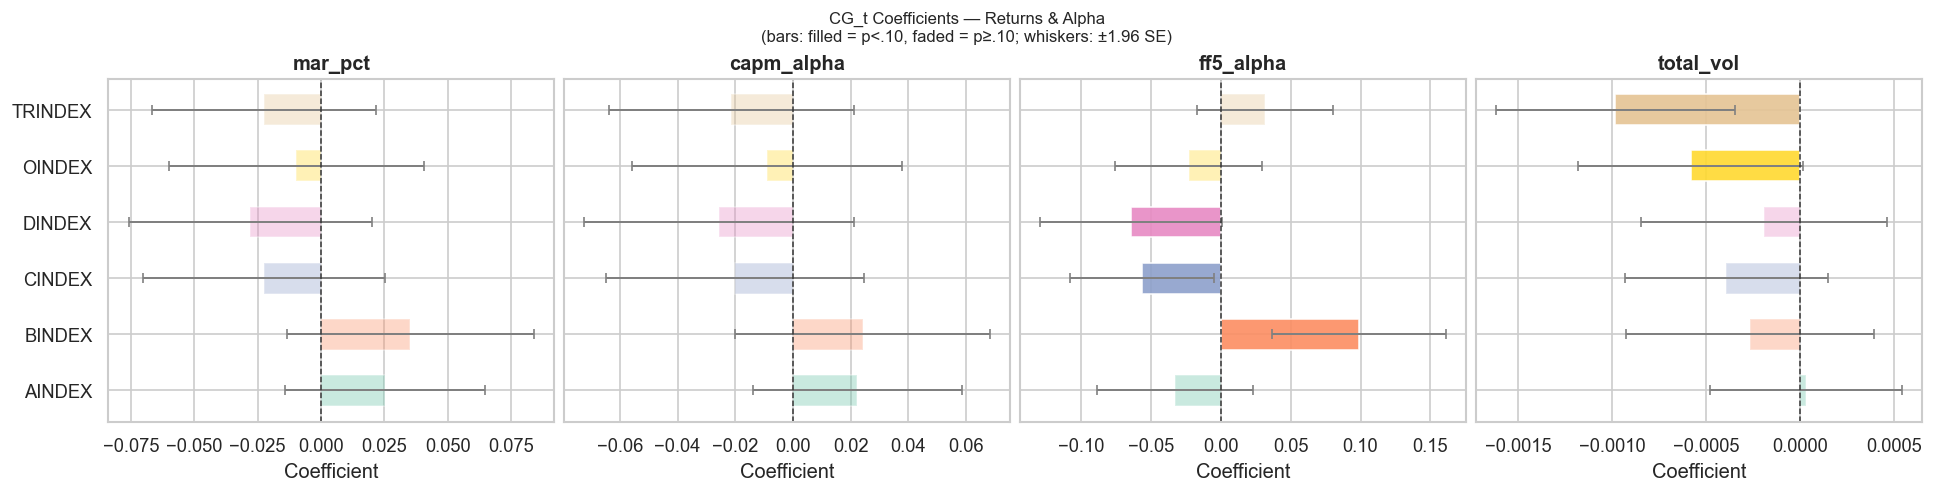

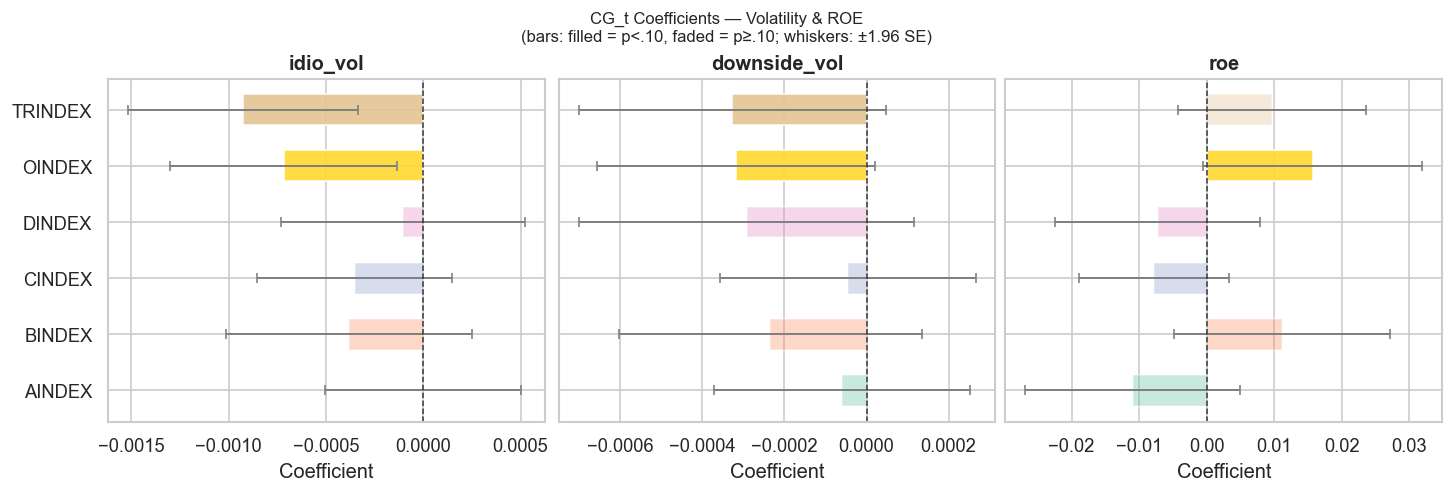

In [7]:
def build_model_df(base_df):
    df = base_df.copy()
    df = pd.concat([df, fe_dummies(df, 'Industry', 'IND'), fe_dummies(df, 'FY', 'FY')], axis=1)
    return df


model_df = build_model_df(panel)
fe_cols_all = [c for c in model_df.columns if c.startswith('_FE_')]
print(f'FE dummy columns: {len(fe_cols_all)}  ({sum(c.startswith("_FE_FY") for c in fe_cols_all)} year, '
      f'{sum(c.startswith("_FE_IND") for c in fe_cols_all)} industry)')

ind_run = {}   # {(outcome, cg): (res, diag)}
for y_col in OUTCOMES:
    for cg in CG_CATS:
        x_cols = [cg] + CTRL + fe_cols_all
        res, diag = run_ols(model_df, y_col, x_cols)
        ind_run[(y_col, cg)] = (res, diag)

print_reg_table(ind_run, OUTCOMES, CG_CATS, title='Individual sub-index regressions: outcome_t+1 ~ CG_t + controls + industry/year FE')
plot_coef_forest(ind_run, OUTCOMES[:4], CG_CATS, 'Returns & Alpha')
plot_coef_forest(ind_run, OUTCOMES[4:], CG_CATS, 'Volatility & ROE')

## 5 — Joint regression (all six sub-indices simultaneously)

`outcome_{t+1} ~ CG_t^AINDEX + ... + CG_t^TRINDEX + controls + industry FE + year FE`.
VIF reported since 07's near-zero sub-index correlations predict this should be stable.

In [8]:
joint_run = {}
for y_col in OUTCOMES:
    x_cols = CG_CATS + CTRL + fe_cols_all
    res, diag = run_ols(model_df, y_col, x_cols)
    joint_run[y_col] = (res, diag)

print_joint_table(joint_run, OUTCOMES, CG_CATS, title='Joint sub-index regression')

_, jd = joint_run.get('mar_pct', (None, None))
if jd is not None and not jd['VIF'].empty:
    print('\nVIF — Joint Model (mar_pct):')
    print(jd['VIF'].to_string(index=False))


  Joint sub-index regression  (joint model)
Variable          mar_pct            capm_alpha          ff5_alpha           total_vol            idio_vol          downside_vol            roe         
----------------------------------------------------------------------------------------------------------------------------------------------------------
AINDEX        +0.0343 (0.0214)    +0.0304 (0.0198)    -0.0288 (0.0284)    +0.0001 (0.0003)    +0.0000 (0.0003)    -0.0000 (0.0002)    -0.0106 (0.0085)  
BINDEX        +0.0317 (0.0237)    +0.0206 (0.0210)  +0.0899*** (0.0295)   -0.0004 (0.0003)   -0.0006* (0.0003)    -0.0003 (0.0002)    +0.0110 (0.0082)  
CINDEX        -0.0271 (0.0242)    -0.0259 (0.0229)   -0.0521* (0.0266)   -0.0006** (0.0003)  -0.0006** (0.0003)   -0.0002 (0.0002)    -0.0069 (0.0062)  
DINDEX       -0.0422* (0.0240)    -0.0379 (0.0230)   -0.0784** (0.0320)   -0.0002 (0.0004)    -0.0001 (0.0003)    -0.0003 (0.0002)    -0.0063 (0.0080)  
OINDEX        -0.0065 (0.0250)    -

## 6 — Composite regression (summary specification)

`outcome_{t+1} ~ CG_t^COMPOSITE + controls + industry FE + year FE`. Reported as a summary
line — the equal-weight mean, not a factor-analytically justified index (per `07`'s
orthogonality finding) — not as the primary evidence.

In [9]:
comp_run = {}
for y_col in OUTCOMES:
    x_cols = ['COMPOSITE'] + CTRL + fe_cols_all
    res, diag = run_ols(model_df, y_col, x_cols)
    comp_run[(y_col, 'COMPOSITE')] = (res, diag)

print_reg_table(comp_run, OUTCOMES, ['COMPOSITE'], title='Composite regression (summary specification)')


  Composite regression (summary specification)
CG Index          mar_pct            capm_alpha          ff5_alpha           total_vol            idio_vol          downside_vol            roe         
                   β (SE)              β (SE)              β (SE)              β (SE)              β (SE)              β (SE)              β (SE)       
----------------------------------------------------------------------------------------------------------------------------------------------------------
COMPOSITE     -0.0118 (0.0228)    -0.0136 (0.0206)    +0.0167 (0.0288)  -0.0009*** (0.0003) -0.0009*** (0.0003)  -0.0005** (0.0002)   +0.0064 (0.0085)  
----------------------------------------------------------------------------------------------------------------------------------------------------------
N                   457                 457                 457                 457                 457                 457                 456         
R²                 0.3677     

## 7 — Romano-Wolf across the (sub-index × outcome) family

6 sub-indices × 7 outcomes = 42 tests, cluster (firm) bootstrap, B=2,000 — same stepdown
procedure as `10_event_study.ipynb`, reused here for a cross-sectional (not time-series)
panel. `np.linalg.inv` (not `pinv`) inside the bootstrap loop is a deliberate speed choice:
with 42 hypotheses × 2,000 draws × a ~75-column design matrix (industry + year FE), `pinv`
takes ~20 minutes; `inv` (falling back to `pinv` only if the resampled design is singular)
takes under a minute, with identical results on well-conditioned draws.

In [10]:
def cluster_ols_fast(y, X, cl_codes, n_clusters, target_idx=1):
    n, k = X.shape
    XtX = X.T @ X
    try:
        XtX_inv = np.linalg.inv(XtX)
    except np.linalg.LinAlgError:
        XtX_inv = np.linalg.pinv(XtX)
    beta = XtX_inv @ (X.T @ y)
    resid = y - X @ beta
    Xr = X * resid[:, None]
    S = np.zeros((n_clusters, k))
    np.add.at(S, cl_codes, Xr)
    meat = S.T @ S
    dof = (n_clusters / max(n_clusters - 1, 1)) * ((n - 1) / max(n - k, 1))
    vcov = XtX_inv @ meat @ XtX_inv * dof
    se = np.sqrt(np.maximum(np.diag(vcov), 0))
    t = beta[target_idx] / se[target_idx] if se[target_idx] > 0 else np.nan
    return beta[target_idx], t


def build_hyp_data(df, fe_cols, outcomes=OUTCOMES, cats=CG_CATS, controls=CTRL):
    hyp = {}
    for cat in cats:
        for y_col in outcomes:
            cols = [y_col, cat] + controls + fe_cols + ['BSE Code']
            sub = df[cols].dropna().reset_index(drop=True)
            if len(sub) < 30:
                continue
            y = winsorize(sub[y_col]).values.astype(float)
            X = np.column_stack([np.ones(len(sub)), sub[cat].values,
                                 sub[controls].values, sub[fe_cols].values]).astype(float)
            firm_rows = pd.Series(np.arange(len(sub))).groupby(sub['BSE Code'].values).apply(np.array).to_dict()
            hyp[(cat, y_col)] = {'y': y, 'X': X, 'firm_rows': firm_rows,
                                 'firms': np.array(list(firm_rows.keys())), 'N': len(sub)}
    return hyp


def _row_cluster_codes(d):
    """Integer cluster code per row, derived from d['firm_rows'] (row indices -> firm id)."""
    row_to_firm = np.empty(len(d['y']), dtype=object)
    for f, rows in d['firm_rows'].items():
        row_to_firm[rows] = f
    codes, uniq = pd.factorize(row_to_firm)
    return codes, len(uniq)


def romano_wolf_cluster(hyp_data, B=RW_B, seed=42):
    keys = list(hyp_data.keys())
    S = len(keys)

    t_orig = np.array([
        cluster_ols_fast(hyp_data[k]['y'], hyp_data[k]['X'], *_row_cluster_codes(hyp_data[k]))[1]
        for k in keys
    ])

    all_firms = np.unique(np.concatenate([hyp_data[k]['firms'] for k in keys]))
    rng = np.random.default_rng(seed)
    boot_t = np.full((B, S), np.nan)
    for b in range(B):
        sampled = rng.choice(all_firms, size=len(all_firms), replace=True)
        for si, k in enumerate(keys):
            d = hyp_data[k]
            present = [f for f in sampled if f in d['firm_rows']]
            if not present:
                continue
            idx = np.concatenate([d['firm_rows'][f] for f in present])
            firm_seq = np.concatenate([[i] * len(d['firm_rows'][f]) for i, f in enumerate(present)])
            _, t_b = cluster_ols_fast(d['y'][idx], d['X'][idx], firm_seq, len(present))
            boot_t[b, si] = t_b

    centered = boot_t - t_orig[None, :]
    order = np.argsort(-np.abs(t_orig))
    p_adj = np.empty(S)
    active = list(order)
    for k in range(S):
        sk = order[k]
        m = np.nanmax(np.abs(centered[:, active]), axis=1)
        p_adj[sk] = np.nanmean(m >= np.abs(t_orig[sk]))
        active.remove(sk)
    running = 0.0
    for k in range(S):
        sk = order[k]
        running = max(running, p_adj[sk])
        p_adj[sk] = running
    return pd.Series(t_orig, index=keys, name='t'), pd.Series(p_adj, index=keys, name='p_rw')


hyp_data = build_hyp_data(model_df, fe_cols_all)
print(f'Hypotheses: {len(hyp_data)}')

t_rw, p_rw = romano_wolf_cluster(hyp_data)
rw_df = pd.DataFrame({'t': t_rw, 'p_rw': p_rw}).reset_index()
rw_df[['Category', 'Outcome']] = pd.DataFrame(rw_df['index'].tolist(), index=rw_df.index)
rw_df = rw_df.drop(columns='index')[['Category', 'Outcome', 't', 'p_rw']].sort_values('p_rw')
rw_df['sig_rw'] = rw_df['p_rw'].apply(sig_stars)

print(rw_df.round(4).to_string(index=False))
print(f"\nSurvive RW p<.10: {(rw_df['p_rw'] < 0.10).sum()} / {len(rw_df)}")

Hypotheses: 42


Category      Outcome       t   p_rw sig_rw
  BINDEX    ff5_alpha  3.1146 0.1085       
 TRINDEX     idio_vol -3.0711 0.1180       
 TRINDEX    total_vol -3.0308 0.1250       
  OINDEX     idio_vol -2.4213 0.4490       
  CINDEX    ff5_alpha -2.1518 0.6675       
  DINDEX    ff5_alpha -1.9377 0.8195       
  OINDEX    total_vol -1.9014 0.8360       
  OINDEX          roe  1.9015 0.8360       
  OINDEX downside_vol -1.8453 0.8510       
 TRINDEX downside_vol -1.7117 0.8985       
  CINDEX    total_vol -1.4149 0.9805       
  BINDEX      mar_pct  1.4133 0.9805       
  DINDEX downside_vol -1.4036 0.9805       
  DINDEX   capm_alpha -1.0715 0.9820       
  DINDEX      mar_pct -1.1396 0.9820       
 TRINDEX    ff5_alpha  1.2683 0.9820       
  CINDEX     idio_vol -1.3785 0.9820       
  AINDEX      mar_pct  1.2561 0.9820       
  CINDEX          roe -1.3855 0.9820       
 TRINDEX          roe  1.3703 0.9820       
  AINDEX   capm_alpha  1.2097 0.9820       
  BINDEX          roe  1.3672 0.

## 8 — Robustness: balanced panel

Restricted to firms present in **both** FY23 and FY24 (T=2, so "all FYs" = both). Re-runs
the individual sub-index regressions on this subsample.

In [11]:
firms_per_fy = panel.groupby('BSE Code')['FY'].apply(set)
balanced_firms = firms_per_fy[firms_per_fy.apply(lambda s: set(FYS).issubset(s))].index
print(f'Firms in both FY23 and FY24: {len(balanced_firms)} / {panel["BSE Code"].nunique()}')

balanced_panel = model_df[model_df['BSE Code'].isin(balanced_firms)].copy()
print(f'Balanced panel rows: {len(balanced_panel)}')

bal_run = {}
for y_col in OUTCOMES:
    for cg in CG_CATS:
        x_cols = [cg] + CTRL + fe_cols_all
        res, diag = run_ols(balanced_panel, y_col, x_cols)
        bal_run[(y_col, cg)] = (res, diag)

print_reg_table(bal_run, OUTCOMES, CG_CATS, title='Balanced-panel robustness: outcome_t+1 ~ CG_t + controls + industry/year FE')

Firms in both FY23 and FY24: 234 / 234
Balanced panel rows: 468



  Balanced-panel robustness: outcome_t+1 ~ CG_t + controls + industry/year FE
CG Index          mar_pct            capm_alpha          ff5_alpha           total_vol            idio_vol          downside_vol            roe         
                   β (SE)              β (SE)              β (SE)              β (SE)              β (SE)              β (SE)              β (SE)       
----------------------------------------------------------------------------------------------------------------------------------------------------------
AINDEX        +0.0252 (0.0201)    +0.0223 (0.0185)    -0.0329 (0.0286)    +0.0000 (0.0003)    -0.0000 (0.0003)    -0.0001 (0.0002)    -0.0110 (0.0081)  
BINDEX        +0.0352 (0.0249)    +0.0241 (0.0225)  +0.0988*** (0.0317)   -0.0003 (0.0003)    -0.0004 (0.0003)    -0.0002 (0.0002)    +0.0112 (0.0082)  
CINDEX        -0.0224 (0.0243)    -0.0200 (0.0228)   -0.0565** (0.0263)   -0.0004 (0.0003)    -0.0004 (0.0003)    -0.0000 (0.0002)    -0.0078 (0.0056)  
D

## Summary and saved outputs

In [12]:
outcomes_df.to_csv(PROC / 'panel_outcomes_forward.csv', index=False)
panel.to_csv(PROC / 'panel_regression_ready.csv', index=False)
rw_df.to_csv(PROC / 'panel_romano_wolf.csv', index=False)

ind_rows = []
for (y_col, cg), (res, diag) in ind_run.items():
    if res is None: continue
    rw_row = rw_df[(rw_df['Category'] == cg) & (rw_df['Outcome'] == y_col)]
    ind_rows.append({'Outcome': y_col, 'Category': cg, 'N': diag['N'],
                     'beta': res.params.get(cg, np.nan), 'se': res.bse.get(cg, np.nan),
                     't': res.tvalues.get(cg, np.nan), 'p_raw': res.pvalues.get(cg, np.nan),
                     'p_rw': rw_row['p_rw'].iloc[0] if len(rw_row) else np.nan})
ind_summary_df = pd.DataFrame(ind_rows)
ind_summary_df.to_csv(PROC / 'panel_individual_regressions.csv', index=False)

comp_summary = []
for y_col in OUTCOMES:
    res, diag = comp_run.get((y_col, 'COMPOSITE'), (None, None))
    if res is not None:
        comp_summary.append({'Outcome': y_col, 'N': diag['N'], 'beta': res.params.get('COMPOSITE', np.nan),
                             'se': res.bse.get('COMPOSITE', np.nan),
                             't': res.tvalues.get('COMPOSITE', np.nan), 'p': res.pvalues.get('COMPOSITE', np.nan)})
comp_summary_df = pd.DataFrame(comp_summary)
comp_summary_df.to_csv(PROC / 'panel_composite_regressions.csv', index=False)

print('=' * 68)
print('  FORWARD-LOOKING PANEL REGRESSION SUMMARY')
print('=' * 68)
print(f'\nPanel: T={len(FYS)} ({FYS}), N={len(panel)} firm-FY obs, {panel["BSE Code"].nunique()} firms')
print(f'Balanced-panel N (firms in both FYs): {len(balanced_firms)}')

print('\n[Individual sub-index regressions — significant at raw p<.10]')
sig_raw = ind_summary_df[ind_summary_df['p_raw'] < 0.10].sort_values('p_raw')
print(sig_raw.round(4).to_string(index=False) if len(sig_raw) else '(none)')

print(f'\n[Romano-Wolf across the 42-test family]')
print(f"  Survive RW p<.10: {(rw_df['p_rw'] < 0.10).sum()} / {len(rw_df)}")
sig_rw = rw_df[rw_df['p_rw'] < 0.10]
print(sig_rw.round(4).to_string(index=False) if len(sig_rw) else '(none)')

print('\n[Composite regression — summary specification]')
print(comp_summary_df.round(4).to_string(index=False))

print('\nSaved:')
for f in ['panel_outcomes_forward.csv', 'panel_regression_ready.csv', 'panel_romano_wolf.csv',
          'panel_individual_regressions.csv', 'panel_composite_regressions.csv']:
    print(f'  -> data/processed/{f}')
print('=' * 68)

  FORWARD-LOOKING PANEL REGRESSION SUMMARY

Panel: T=2 (['FY23', 'FY24']), N=468 firm-FY obs, 234 firms
Balanced-panel N (firms in both FYs): 234

[Individual sub-index regressions — significant at raw p<.10]
     Outcome Category   N    beta     se       t  p_raw   p_rw
   ff5_alpha   BINDEX 437  0.0988 0.0317  3.1146 0.0021 0.1085
    idio_vol  TRINDEX 437 -0.0009 0.0003 -3.0711 0.0024 0.1180
   total_vol  TRINDEX 437 -0.0010 0.0003 -3.0308 0.0027 0.1250
    idio_vol   OINDEX 437 -0.0007 0.0003 -2.4213 0.0163 0.4490
   ff5_alpha   CINDEX 457 -0.0565 0.0263 -2.1518 0.0325 0.6675
   ff5_alpha   DINDEX 437 -0.0642 0.0331 -1.9377 0.0540 0.8195
         roe   OINDEX 436  0.0157 0.0083  1.9015 0.0585 0.8360
   total_vol   OINDEX 437 -0.0006 0.0003 -1.9014 0.0586 0.8360
downside_vol   OINDEX 437 -0.0003 0.0002 -1.8453 0.0663 0.8510
downside_vol  TRINDEX 437 -0.0003 0.0002 -1.7117 0.0884 0.8985

[Romano-Wolf across the 42-test family]
  Survive RW p<.10: 0 / 42
(none)

[Composite regression 

## 9 — Integration: Annual Report and Reg 30 governance variables

New right-hand-side variables of interest, built entirely outside this notebook (see
`ar_extractor.py`, `reg30_firm_fy_agg.py`, `INTEGRATION_NOTES.md`) and merged in here as
new sections — **nothing above this cell is modified**; Table A reproduces unchanged.

**Reg30** (`reg30_firm_fy.csv`) is collapsed from Reg 30 (SEBI LODR) event disclosures —
director changes, credit rating actions, auditor changes — extracted via LLM from BSE
announcement filings for a 100-firm stratified sub-sample of the 247-firm universe, then
collapsed quarter -> FY with the identical `'FY' + Q_FY.str[-2:]` convention this notebook
already uses. Only FY23/FY24 rows can ever reach this panel (see below) — FY25 was
computed and saved for completeness but this notebook's panel is T=2 (FY23/FY24 only, per
Section 1's empirical determination), so FY25 rows have nothing to merge onto.

**AR** (`ar_features_firm_fy.csv`) extracts NEW quantitative constructs from the 739
Annual Report PDFs (board size/independence/meetings, audit fees, RPT value, promoter
pledge, contingent liabilities) — explicitly NOT re-scoring what the CG index's A8/D2-D5
already cover (that comparison is a separate robustness exhibit, not mixed in here).

Both are merged **`how='left'`** onto the existing `panel` — the 236-firm/472-row Table A
base can only grow variables, never shrink rows, from these merges alone.

In [13]:
ar = pd.read_csv(PROC / 'ar_features_firm_fy.csv')
ar['BSE Code'] = pd.to_numeric(ar['BSE Code'], errors='coerce')
reg30 = pd.read_csv(PROC / 'reg30_firm_fy.csv')
reg30['BSE Code'] = pd.to_numeric(reg30['BSE Code'], errors='coerce')

print(f'AR features: {len(ar)} rows (739 firm-FY, full run)')
print(f'Reg30 firm-FY: {len(reg30)} rows (100 firms x FY23-FY25)')

# AR_VARS: coverage-driven selection, not hardcoded — computed fresh against
# whatever's actually in ar_features_firm_fy.csv, within the Table A panel
# (the population these variables will actually be used on).
AR_CANDIDATE_FIELDS = ['board_size', 'board_independence_ratio', 'board_meeting_count',
                       'board_avg_attendance_pct', 'promoter_pledge_pct',
                       'rpt_aggregate_inr_crore', 'audit_fees_inr_crore',
                       'contingent_liabilities_inr_crore']
AR_COVERAGE_THRESHOLD = 0.20  # a field below this is too sparse to be a usable continuous
                              # regressor under FE, per ar_extractor.py's own reporting convention

ar_in_panel = panel[['BSE Code', 'FY']].merge(ar, on=['BSE Code', 'FY'], how='left')
coverage_df = pd.DataFrame({
    'field': AR_CANDIDATE_FIELDS,
    'coverage_pct': [ar_in_panel[f].notna().mean() * 100 for f in AR_CANDIDATE_FIELDS],
}).sort_values('coverage_pct', ascending=False)
coverage_df['recommended'] = coverage_df['coverage_pct'] >= AR_COVERAGE_THRESHOLD * 100
coverage_df.to_csv(PROC / 'ar_field_coverage.csv', index=False)

print('\nAR field coverage within the Table A panel (236 firms x FY23/FY24):')
print(coverage_df.round(1).to_string(index=False))

AR_VARS = coverage_df.loc[coverage_df['recommended'], 'field'].tolist()
print(f'\nAR_VARS (>= {AR_COVERAGE_THRESHOLD:.0%} coverage): {AR_VARS}')
print(f'Excluded as too sparse: {coverage_df.loc[~coverage_df["recommended"], "field"].tolist()}')
print('(sparse here means the extractor rarely located/confirmed the disclosure at all —')
print(' not that the true values cluster at an uninformative constant like 0% pledge)')

AR features: 739 rows (739 firm-FY, full run)
Reg30 firm-FY: 300 rows (100 firms x FY23-FY25)

AR field coverage within the Table A panel (236 firms x FY23/FY24):
                           field  coverage_pct  recommended
            audit_fees_inr_crore       53.8000         True
                      board_size       27.1000         True
        board_independence_ratio       27.1000         True
             board_meeting_count       22.4000         True
contingent_liabilities_inr_crore       11.3000        False
             promoter_pledge_pct        4.1000        False
         rpt_aggregate_inr_crore        2.1000        False
        board_avg_attendance_pct        0.2000        False

AR_VARS (>= 20% coverage): ['audit_fees_inr_crore', 'board_size', 'board_independence_ratio', 'board_meeting_count']
Excluded as too sparse: ['contingent_liabilities_inr_crore', 'promoter_pledge_pct', 'rpt_aggregate_inr_crore', 'board_avg_attendance_pct']
(sparse here means the extractor rarely 

### 9.1 — Table B: `CG_t + AR_t + controls + FE`

**Design note — a deviation from the original one-joint-model reading, forced by measured
data, not assumed:** `AR_VARS`' missingness is not correlated (a document can have a clean
board table but no locatable audit-fee line, or vice versa) — requiring all `AR_VARS`
simultaneously non-null in one model drops the usable sample to N=24, under `run_ols`'s
own N>=30 floor. Verified against the real coverage numbers before writing this: CG(6,
joint) + **one** AR variable at a time comfortably clears the floor (96-252 obs per
variable). So Table B is `CG_t^AINDEX + ... + CG_t^TRINDEX + AR_t^(one var) + controls +
FE`, run once per `AR_VARS` entry x 7 outcomes — mirroring Table A's own joint
specification (Section 5), just with one AR variable appended at a time instead of trying
to cram all of them in together.

The Romano-Wolf family is unaffected by this — `build_hyp_data` already tests each
variable univariately (that variable + controls + FE only, not jointly with the other CG
sub-indices), so it never had the joint-missingness problem in the first place.

In [14]:
panel_b = panel.merge(ar[['BSE Code', 'FY'] + AR_VARS], on=['BSE Code', 'FY'], how='left')
assert len(panel_b) == len(panel), 'left-merge must not change the Table A row count'

model_df_b = build_model_df(panel_b)
fe_cols_b = [c for c in model_df_b.columns if c.startswith('_FE_')]

joint_run_b = {}
for ar_var in AR_VARS:
    for y_col in OUTCOMES:
        x_cols = CG_CATS + [ar_var] + CTRL + fe_cols_b
        res, diag = run_ols(model_df_b, y_col, x_cols)
        joint_run_b[(y_col, ar_var)] = (res, diag)

n_ok = sum(1 for r, _ in joint_run_b.values() if r is not None)
print(f'Table B: {n_ok}/{len(joint_run_b)} (outcome, AR-var) models estimable')

print('\nTable B — AR variable coefficients (CG_t jointly included but not shown; see CG stability check below):')
for ar_var in AR_VARS:
    print(f'\n  {ar_var}:')
    for y_col in OUTCOMES:
        res, diag = joint_run_b.get((y_col, ar_var), (None, None))
        if res is None:
            print(f'    {y_col:14s}  N/A (N<30)')
            continue
        coef, se, p = res.params.get(ar_var, np.nan), res.bse.get(ar_var, np.nan), res.pvalues.get(ar_var, np.nan)
        print(f'    {y_col:14s}  {coef:+.4f}{sig_stars(p)} ({se:.4f})   N={diag["N"]}')

Table B: 28/28 (outcome, AR-var) models estimable

Table B — AR variable coefficients (CG_t jointly included but not shown; see CG stability check below):

  audit_fees_inr_crore:
    mar_pct         -0.0000*** (0.0000)   N=235
    capm_alpha      -0.0000*** (0.0000)   N=235
    ff5_alpha       -0.0000** (0.0000)   N=235
    total_vol       -0.0000 (0.0000)   N=235
    idio_vol        +0.0000** (0.0000)   N=235
    downside_vol    +0.0000 (0.0000)   N=235
    roe             +0.0000 (0.0000)   N=235

  board_size:
    mar_pct         +0.0390 (0.0419)   N=117
    capm_alpha      +0.0260 (0.0308)   N=117
    ff5_alpha       +0.0280 (0.0481)   N=117
    total_vol       -0.0003 (0.0003)   N=117
    idio_vol        -0.0003 (0.0002)   N=117
    downside_vol    -0.0001 (0.0001)   N=117
    roe             -0.0027 (0.0062)   N=117

  board_independence_ratio:
    mar_pct         +0.7429 (1.1962)   N=117
    capm_alpha      +0.3530 (0.8203)   N=117
    ff5_alpha       -2.1140 (1.4501)   N=117
 

In [15]:
# Table B Romano-Wolf family (separate from Table A's 42-test family and from Table
# C's family below — different variable sets, and Table C runs on a different, smaller
# sample, so a single combined family would compare hypotheses of very different N against
# each other inside the same max-statistic stepdown, which is the wrong comparison).
hyp_data_b = build_hyp_data(model_df_b, fe_cols_b, cats=CG_CATS + AR_VARS)
print(f'Table B RW family: {len(hyp_data_b)} hypotheses (({len(CG_CATS)} CG + {len(AR_VARS)} AR) x {len(OUTCOMES)} outcomes)')

t_rw_b, p_rw_b = romano_wolf_cluster(hyp_data_b, B=RW_B)
rw_df_b = pd.DataFrame({'t': t_rw_b, 'p_rw': p_rw_b}).reset_index()
rw_df_b[['Variable', 'Outcome']] = pd.DataFrame(rw_df_b['index'].tolist(), index=rw_df_b.index)
rw_df_b = rw_df_b.drop(columns='index')[['Variable', 'Outcome', 't', 'p_rw']].sort_values('p_rw')
rw_df_b['sig_rw'] = rw_df_b['p_rw'].apply(sig_stars)

print(rw_df_b.round(4).to_string(index=False))
print(f"\nSurvive RW p<.10: {(rw_df_b['p_rw'] < 0.10).sum()} / {len(rw_df_b)}")

Table B RW family: 70 hypotheses ((6 CG + 4 AR) x 7 outcomes)


                Variable      Outcome       t   p_rw sig_rw
    audit_fees_inr_crore     idio_vol  4.7336 0.4320       
    audit_fees_inr_crore      mar_pct -4.3348 0.4320       
    audit_fees_inr_crore    ff5_alpha -3.7854 0.4745       
    audit_fees_inr_crore   capm_alpha -4.0256 0.4745       
                  BINDEX    ff5_alpha  3.1146 0.5085       
                 TRINDEX     idio_vol -3.0711 0.5190       
                 TRINDEX    total_vol -3.0308 0.5280       
    audit_fees_inr_crore          roe -2.5607 0.7395       
                  OINDEX     idio_vol -2.4213 0.7395       
                  CINDEX    ff5_alpha -2.1518 0.8550       
    audit_fees_inr_crore downside_vol  2.1093 0.8690       
board_independence_ratio     idio_vol  2.0507 0.8700       
board_independence_ratio    total_vol  1.9430 0.9205       
                  DINDEX    ff5_alpha -1.9377 0.9220       
                  OINDEX    total_vol -1.9014 0.9270       
                  OINDEX          roe  1

In [16]:
# Table B balanced-panel robustness — mirrors Section 8's logic exactly, on panel_b.
firms_per_fy_b = panel_b.groupby('BSE Code')['FY'].apply(set)
balanced_firms_b = firms_per_fy_b[firms_per_fy_b.apply(lambda s: set(FYS).issubset(s))].index
print(f'Table B — firms in both FY23 and FY24: {len(balanced_firms_b)} / {panel_b["BSE Code"].nunique()}')

balanced_panel_b = model_df_b[model_df_b['BSE Code'].isin(balanced_firms_b)].copy()
bal_run_b = {}
for ar_var in AR_VARS:
    for y_col in OUTCOMES:
        x_cols = CG_CATS + [ar_var] + CTRL + fe_cols_b
        res, diag = run_ols(balanced_panel_b, y_col, x_cols)
        bal_run_b[(y_col, ar_var)] = (res, diag)
n_ok_bal_b = sum(1 for r, _ in bal_run_b.values() if r is not None)
print(f'Table B balanced-panel: {n_ok_bal_b}/{len(bal_run_b)} models estimable')

Table B — firms in both FY23 and FY24: 234 / 234


Table B balanced-panel: 28/28 models estimable


### 9.2 — Table C: `CG_t + AR_t + Reg30_t + controls + FE` (covered subsample)

Restricted to the ~96-100 firms actually covered by the Reg 30 sample (a **stratified
sample by design, not a missing-at-random gap** — see `INTEGRATION_NOTES.md`) — the whole
model (`CG_t`, `AR_t`, and `Reg30_t` together) runs on this smaller, common sample so `CG_t`
coefficients are directly comparable to Tables A/B as a stability check, per the original
design brief. `REG30_VARS` enter jointly (all 3 together) rather than one-at-a-time like
`AR_VARS` — their coverage is complete-by-construction within the covered sample (the
firm-quarter aggregation zero-fills genuine non-events, it doesn't leave gaps), so there's
no missingness problem to work around there.

In [17]:
reg30_covered_firms = set(reg30.loc[reg30['reg30_covered'] == 1, 'BSE Code'].unique())
REG30_VARS = ['n_director_changes', 'n_rating_changes', 'auditor_change_any']

panel_c = panel_b.merge(reg30[['BSE Code', 'FY'] + REG30_VARS], on=['BSE Code', 'FY'], how='left')
panel_c = panel_c[panel_c['BSE Code'].isin(reg30_covered_firms)].copy()
print(f"Table C covered subsample: {panel_c['BSE Code'].nunique()} firms (of Table A's "
      f"{panel['BSE Code'].nunique()}), {len(panel_c)} firm-FY rows")

model_df_c = build_model_df(panel_c)
fe_cols_c = [c for c in model_df_c.columns if c.startswith('_FE_')]

joint_run_c = {}
for ar_var in AR_VARS:
    for y_col in OUTCOMES:
        x_cols = CG_CATS + [ar_var] + REG30_VARS + CTRL + fe_cols_c
        res, diag = run_ols(model_df_c, y_col, x_cols)
        joint_run_c[(y_col, ar_var)] = (res, diag)
n_ok_c = sum(1 for r, _ in joint_run_c.values() if r is not None)
print(f'Table C: {n_ok_c}/{len(joint_run_c)} (outcome, AR-var) models estimable')

print('\nTable C — Reg30 variable coefficients (audit_fees_inr_crore spec shown as representative; CG jointly included):')
rep_ar_var = 'audit_fees_inr_crore' if 'audit_fees_inr_crore' in AR_VARS else AR_VARS[0]
for y_col in OUTCOMES:
    res, diag = joint_run_c.get((y_col, rep_ar_var), (None, None))
    if res is None:
        print(f'  {y_col:14s}  N/A (N<30)')
        continue
    parts = [f'{v}={res.params.get(v, np.nan):+.4f}{sig_stars(res.pvalues.get(v, np.nan))}' for v in REG30_VARS]
    print(f'  {y_col:14s}  N={diag["N"]:3d}  ' + '  '.join(parts))

Table C covered subsample: 95 firms (of Table A's 234), 190 firm-FY rows


Table C: 28/28 (outcome, AR-var) models estimable

Table C — Reg30 variable coefficients (audit_fees_inr_crore spec shown as representative; CG jointly included):
  mar_pct         N= 93  n_director_changes=+0.0151  n_rating_changes=-0.0022  auditor_change_any=-0.0267
  capm_alpha      N= 93  n_director_changes=+0.0086  n_rating_changes=+0.0000  auditor_change_any=+0.0468
  ff5_alpha       N= 93  n_director_changes=+0.0050  n_rating_changes=-0.0372  auditor_change_any=+0.1569
  total_vol       N= 93  n_director_changes=+0.0001  n_rating_changes=-0.0001  auditor_change_any=-0.0012
  idio_vol        N= 93  n_director_changes=-0.0001  n_rating_changes=-0.0002  auditor_change_any=-0.0013
  downside_vol    N= 93  n_director_changes=-0.0001  n_rating_changes=-0.0005  auditor_change_any=-0.0000
  roe             N= 93  n_director_changes=-0.0021  n_rating_changes=-0.0188  auditor_change_any=+0.0193


In [18]:
# CG coefficient stability check across Tables A -> B -> C (the explicit purpose of
# running Table C's CG_t on the same restricted sample as AR_t/Reg30_t) — reported
# honestly: this is NOT expected to be identical (smaller, different sample each time),
# the question is whether it's in the same ballpark or swings wildly.
print('CG coefficient stability across tables (representative AR var: ' + rep_ar_var + ')')
print(f"{'':10s}{'Table A':>12s}{'Table B':>12s}{'Table C':>12s}")
for cg in CG_CATS:
    res_a, _ = ind_run.get(('mar_pct', cg), (None, None))
    res_b, _ = joint_run_b.get(('mar_pct', rep_ar_var), (None, None))
    res_c, _ = joint_run_c.get(('mar_pct', rep_ar_var), (None, None))
    va = res_a.params.get(cg, np.nan) if res_a is not None else np.nan
    vb = res_b.params.get(cg, np.nan) if res_b is not None else np.nan
    vc = res_c.params.get(cg, np.nan) if res_c is not None else np.nan
    print(f'{cg:10s}{va:>12.4f}{vb:>12.4f}{vc:>12.4f}')
print('(outcome shown: mar_pct — see saved CSVs for the full outcome x table grid)')

CG coefficient stability across tables (representative AR var: audit_fees_inr_crore)
               Table A     Table B     Table C
AINDEX          0.0252     -0.0131     -0.0195
BINDEX          0.0352      0.0329      0.0152
CINDEX         -0.0224     -0.0510     -0.2085
DINDEX         -0.0279     -0.0214     -0.0162
OINDEX         -0.0098     -0.0656     -0.2001
TRINDEX        -0.0224      0.0027     -0.0132
(outcome shown: mar_pct — see saved CSVs for the full outcome x table grid)


In [19]:
# Table C Romano-Wolf family — separate from Tables A and B (Option B: per-table
# families, agreed given Table C runs on a materially different, smaller sample; see
# INTEGRATION_NOTES.md for the full reasoning).
hyp_data_c = build_hyp_data(model_df_c, fe_cols_c, cats=CG_CATS + AR_VARS + REG30_VARS)
print(f'Table C RW family: {len(hyp_data_c)} hypotheses')

t_rw_c, p_rw_c = romano_wolf_cluster(hyp_data_c, B=RW_B)
rw_df_c = pd.DataFrame({'t': t_rw_c, 'p_rw': p_rw_c}).reset_index()
rw_df_c[['Variable', 'Outcome']] = pd.DataFrame(rw_df_c['index'].tolist(), index=rw_df_c.index)
rw_df_c = rw_df_c.drop(columns='index')[['Variable', 'Outcome', 't', 'p_rw']].sort_values('p_rw')
rw_df_c['sig_rw'] = rw_df_c['p_rw'].apply(sig_stars)

print(rw_df_c.round(4).to_string(index=False))
print(f"\nSurvive RW p<.10: {(rw_df_c['p_rw'] < 0.10).sum()} / {len(rw_df_c)}")

Table C RW family: 91 hypotheses


                Variable      Outcome       t   p_rw sig_rw
    audit_fees_inr_crore    ff5_alpha -2.1302 0.9940       
    audit_fees_inr_crore   capm_alpha -1.8352 0.9995       
      auditor_change_any    ff5_alpha  1.8497 0.9995       
      auditor_change_any   capm_alpha  1.7565 0.9995       
                  AINDEX      mar_pct  1.3534 1.0000       
     board_meeting_count   capm_alpha -0.5174 1.0000       
     board_meeting_count      mar_pct -0.4818 1.0000       
board_independence_ratio          roe -0.5501 1.0000       
board_independence_ratio downside_vol  0.4452 1.0000       
board_independence_ratio     idio_vol  0.7162 1.0000       
board_independence_ratio    total_vol  0.6701 1.0000       
board_independence_ratio    ff5_alpha -0.3597 1.0000       
board_independence_ratio   capm_alpha  0.5894 1.0000       
              board_size downside_vol -0.1132 1.0000       
              board_size          roe -0.0751 1.0000       
              board_size     idio_vol  0

In [20]:
# Table C balanced-panel robustness.
firms_per_fy_c = panel_c.groupby('BSE Code')['FY'].apply(set)
balanced_firms_c = firms_per_fy_c[firms_per_fy_c.apply(lambda s: set(FYS).issubset(s))].index
print(f'Table C — firms in both FY23 and FY24: {len(balanced_firms_c)} / {panel_c["BSE Code"].nunique()}')

balanced_panel_c = model_df_c[model_df_c['BSE Code'].isin(balanced_firms_c)].copy()
bal_run_c = {}
for ar_var in AR_VARS:
    for y_col in OUTCOMES:
        x_cols = CG_CATS + [ar_var] + REG30_VARS + CTRL + fe_cols_c
        res, diag = run_ols(balanced_panel_c, y_col, x_cols)
        bal_run_c[(y_col, ar_var)] = (res, diag)
n_ok_bal_c = sum(1 for r, _ in bal_run_c.values() if r is not None)
print(f'Table C balanced-panel: {n_ok_bal_c}/{len(bal_run_c)} models estimable')

Table C — firms in both FY23 and FY24: 95 / 95


Table C balanced-panel: 28/28 models estimable


### 9.3 — Save outputs

Distinct filenames throughout — none of Table A's saved artifacts
(`panel_regression_ready.csv`, `panel_romano_wolf.csv`, etc.) are overwritten.

In [21]:
panel_b.to_csv(PROC / 'panel_regression_ready_b.csv', index=False)
panel_c.to_csv(PROC / 'panel_regression_ready_c.csv', index=False)
rw_df_b.to_csv(PROC / 'panel_romano_wolf_b.csv', index=False)
rw_df_c.to_csv(PROC / 'panel_romano_wolf_c.csv', index=False)

def _flatten(joint_run, label):
    rows = []
    for (y_col, ar_var), (res, diag) in joint_run.items():
        if res is None:
            continue
        row = {'Outcome': y_col, 'AR_var': ar_var, 'N': diag['N']}
        for v in (CG_CATS + [ar_var] + (REG30_VARS if label == 'C' else [])):
            if v in res.params.index:
                row[f'{v}_beta'] = res.params[v]
                row[f'{v}_p'] = res.pvalues[v]
        rows.append(row)
    return pd.DataFrame(rows)

_flatten(joint_run_b, 'B').to_csv(PROC / 'panel_joint_regressions_b.csv', index=False)
_flatten(joint_run_c, 'C').to_csv(PROC / 'panel_joint_regressions_c.csv', index=False)

print('Saved:')
for f in ['ar_field_coverage.csv', 'panel_regression_ready_b.csv', 'panel_regression_ready_c.csv',
          'panel_romano_wolf_b.csv', 'panel_romano_wolf_c.csv',
          'panel_joint_regressions_b.csv', 'panel_joint_regressions_c.csv']:
    print(f'  -> data/processed/{f}')

print('\n' + '=' * 68)
print('  TABLE B/C SUMMARY')
print('=' * 68)
print(f"Table A (reference) : N={len(panel)}, {panel['BSE Code'].nunique()} firms — UNCHANGED")
print(f"Table B (CG+AR)     : N={len(panel_b)}, {panel_b['BSE Code'].nunique()} firms, "
      f"AR_VARS={AR_VARS}")
print(f"Table C (CG+AR+Reg30, covered): N={len(panel_c)}, {panel_c['BSE Code'].nunique()} firms")
print(f"Table B RW survivors (p<.10): {(rw_df_b['p_rw'] < 0.10).sum()} / {len(rw_df_b)}")
print(f"Table C RW survivors (p<.10): {(rw_df_c['p_rw'] < 0.10).sum()} / {len(rw_df_c)}")
print('=' * 68)

Saved:
  -> data/processed/ar_field_coverage.csv
  -> data/processed/panel_regression_ready_b.csv
  -> data/processed/panel_regression_ready_c.csv
  -> data/processed/panel_romano_wolf_b.csv
  -> data/processed/panel_romano_wolf_c.csv
  -> data/processed/panel_joint_regressions_b.csv
  -> data/processed/panel_joint_regressions_c.csv

  TABLE B/C SUMMARY
Table A (reference) : N=468, 234 firms — UNCHANGED
Table B (CG+AR)     : N=468, 234 firms, AR_VARS=['audit_fees_inr_crore', 'board_size', 'board_independence_ratio', 'board_meeting_count']
Table C (CG+AR+Reg30, covered): N=190, 95 firms
Table B RW survivors (p<.10): 0 / 70
Table C RW survivors (p<.10): 0 / 91


## 10 — Corrected primary specification (Phase-2 fixes)

Two design-level fixes to Table A, decided in advance on diagnostic grounds (see
`diagnostics.py` and the Phase-1 verdict) — **not** chosen after looking at Table A's
p-values. Nothing above this cell is modified; Table A/B/C reproduce unchanged.

**Fix 1 — DINDEX is dropped.** Its D2-D5 components fail LLM scoring on 61-67% of
observations (recomputed below from `numerical_indices.xlsx`), and the resulting
near-constant regressor after imputation cannot identify anything — reported as
non-estimable, not rescued by re-imputing. `CG_CATS_PRIMARY` is therefore 5 sub-indices,
and `COMPOSITE_5` is rebuilt as the mean of those 5 (not the original 6-index
`COMPOSITE`), each VdW-transformed exactly as Section 2 does.

**Fix 2 — singleton-industry firms are dropped.** 26 of the panel's 69 industries have
exactly one firm; those firms contribute zero within-industry identifying variation
once industry FE are absorbed, and are dropped from the primary spec (not from Table A/B/C
above, which stand as originally run). A **Sector-FE robustness version** is reported
alongside (11 sectors, 0 singletons, no firm dropped) — broader FE trades away
within-industry precision for omitted-variable risk (sector groups firms that may differ a
lot on unmeasured fundamentals), so it is a robustness check, not the headline.

In [22]:
ni_check = pd.read_excel(RAW / 'numerical_indices.xlsx')
print('DINDEX component failure/placeholder rates (non-numeric Score by metric ID):')
for mid in ['D2', 'D3', 'D4', 'D5']:
    sub = ni_check[ni_check['ID'] == mid]
    numeric = pd.to_numeric(sub['Score'], errors='coerce')
    print(f'  {mid}: N={len(sub)}  failed={numeric.isna().sum()} ({numeric.isna().mean():.1%})')
print('-> DINDEX dropped from the primary spec on these grounds.')

CG_CATS_PRIMARY = [c for c in CG_CATS if c != 'DINDEX']
print(f'\nCG_CATS_PRIMARY: {CG_CATS_PRIMARY}')

# COMPOSITE_5 — mean of the 5 primary sub-indices' RAW Avg_Score, VdW-transformed on its
# own per FY cross-section (mirrors exactly how Section 2 builds the original 6-index
# COMPOSITE — just excluding DINDEX from the average before transforming).
cg_a5 = scores[scores['FY'].isin(FYS) & scores['Category'].isin(CG_CATS_PRIMARY)]
cg_a5_avg = cg_a5.groupby(['BSE Code', 'FY', 'Category'])['Avg_Score'].mean().reset_index()
comp5_raw = cg_a5_avg.groupby(['BSE Code', 'FY'])['Avg_Score'].mean().reset_index()
comp5_raw['COMPOSITE_5'] = comp5_raw.groupby('FY')['Avg_Score'].transform(vdw_score)
panel = panel.merge(comp5_raw[['BSE Code', 'FY', 'COMPOSITE_5']], on=['BSE Code', 'FY'], how='left')
print(f'COMPOSITE_5 rebuilt: {panel["COMPOSITE_5"].notna().sum()} / {len(panel)} rows')

DINDEX component failure/placeholder rates (non-numeric Score by metric ID):
  D2: N=4600  failed=3028 (65.8%)
  D3: N=4600  failed=2891 (62.8%)
  D4: N=4600  failed=3099 (67.4%)
  D5: N=4600  failed=2808 (61.0%)
-> DINDEX dropped from the primary spec on these grounds.

CG_CATS_PRIMARY: ['AINDEX', 'BINDEX', 'CINDEX', 'OINDEX', 'TRINDEX']
COMPOSITE_5 rebuilt: 468 / 468 rows


In [23]:
imap_sector = pd.read_excel(PROC / 'industry_map.xlsx')[['BSE Code', 'Sector']]
imap_sector['BSE Code'] = pd.to_numeric(imap_sector['BSE Code'], errors='coerce')
panel = panel.merge(imap_sector, on='BSE Code', how='left')

ind_firm_counts = panel.groupby('Industry')['BSE Code'].nunique()
singleton_industries = ind_firm_counts[ind_firm_counts == 1].index.tolist()
singleton_firms = panel.loc[panel['Industry'].isin(singleton_industries), 'BSE Code'].unique()
print(f'Industries: {ind_firm_counts.shape[0]}, singleton (1 firm): {len(singleton_industries)}')
print(f'Firms dropped from the primary spec: {len(singleton_firms)} / {panel["BSE Code"].nunique()}')

panel_primary = panel[~panel['BSE Code'].isin(singleton_firms)].copy()
ind_firm_counts_primary = panel_primary.groupby('Industry')['BSE Code'].nunique()
print(f'Primary-spec panel: {panel_primary["BSE Code"].nunique()} firms, {len(panel_primary)} firm-FY rows, '
      f'{ind_firm_counts_primary.shape[0]} industries (min firms/industry = {ind_firm_counts_primary.min()})')
print('-> Every remaining industry has >=2 firms: the CG coefficient is now identified off '
      'genuine within-industry variation, not mechanically absorbed by a singleton dummy.')

model_df_primary = build_model_df(panel_primary)
fe_cols_primary = [c for c in model_df_primary.columns if c.startswith('_FE_')]
n_regressors_primary = len(CG_CATS_PRIMARY) + len(CTRL) + len(fe_cols_primary) + 1
print(f'\nFE dummies: {len(fe_cols_primary)} ({sum(c.startswith("_FE_IND") for c in fe_cols_primary)} industry, '
      f'{sum(c.startswith("_FE_FY") for c in fe_cols_primary)} year)')
print(f'Individual-spec regressor budget: {n_regressors_primary} vs N={len(panel_primary)} '
      f'-> residual df={len(panel_primary) - n_regressors_primary} '
      f'(FE share={len(fe_cols_primary)/n_regressors_primary:.1%}, vs 92.0% in Table A)')

Industries: 68, singleton (1 firm): 25
Firms dropped from the primary spec: 25 / 234
Primary-spec panel: 209 firms, 418 firm-FY rows, 43 industries (min firms/industry = 2)
-> Every remaining industry has >=2 firms: the CG coefficient is now identified off genuine within-industry variation, not mechanically absorbed by a singleton dummy.

FE dummies: 43 (42 industry, 1 year)
Individual-spec regressor budget: 53 vs N=418 -> residual df=365 (FE share=81.1%, vs 92.0% in Table A)


### 10.1 — Individual sub-index regressions (primary spec)


  PRIMARY SPEC: outcome_t+1 ~ CG_t + controls + industry/year FE (singleton industries dropped, DINDEX excluded)
CG Index          mar_pct            capm_alpha          ff5_alpha           total_vol            idio_vol          downside_vol            roe         
                   β (SE)              β (SE)              β (SE)              β (SE)              β (SE)              β (SE)              β (SE)       
----------------------------------------------------------------------------------------------------------------------------------------------------------
AINDEX        +0.0255 (0.0199)    +0.0211 (0.0182)    -0.0340 (0.0277)    +0.0000 (0.0003)    -0.0000 (0.0003)    -0.0001 (0.0002)    -0.0113 (0.0077)  
BINDEX       +0.0473* (0.0253)    +0.0328 (0.0230)  +0.0922*** (0.0323)   -0.0002 (0.0003)    -0.0003 (0.0003)    -0.0002 (0.0002)    +0.0108 (0.0079)  
CINDEX        -0.0235 (0.0241)    -0.0209 (0.0228)   -0.0514** (0.0256)   -0.0004 (0.0003)    -0.0003 (0.0003)    -0.00

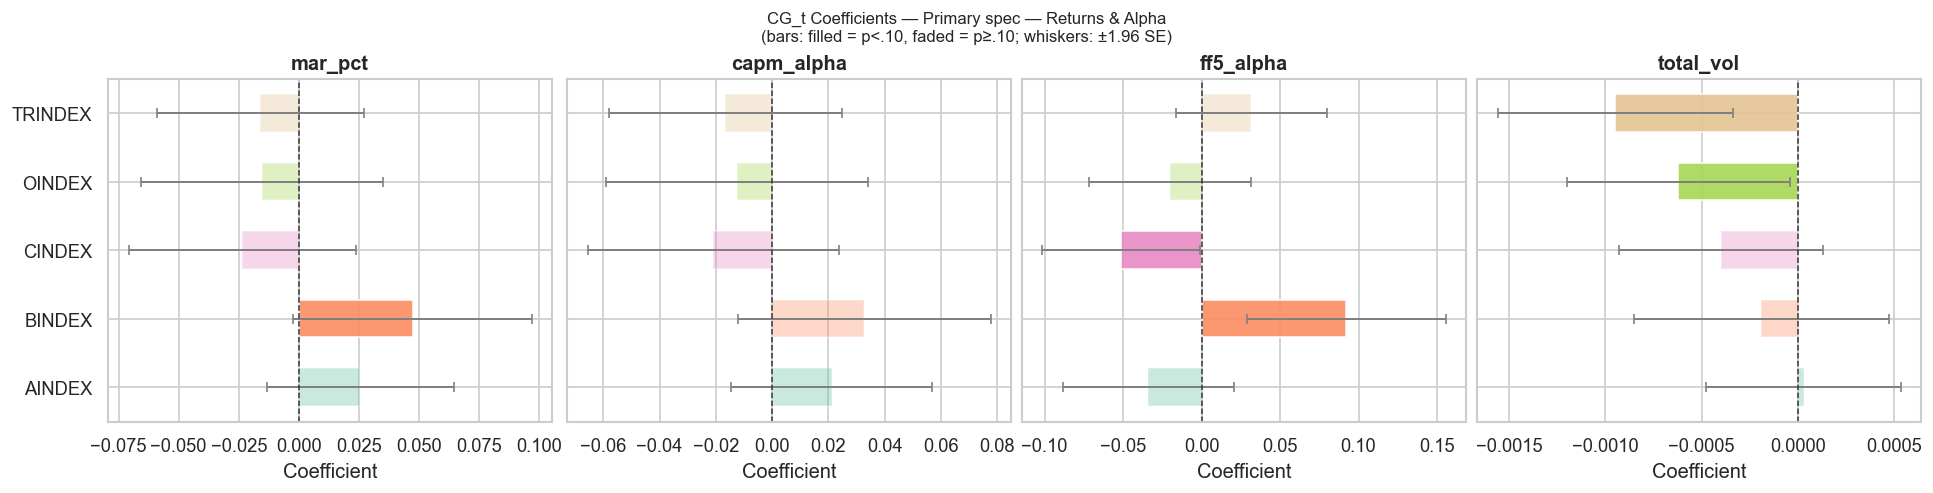

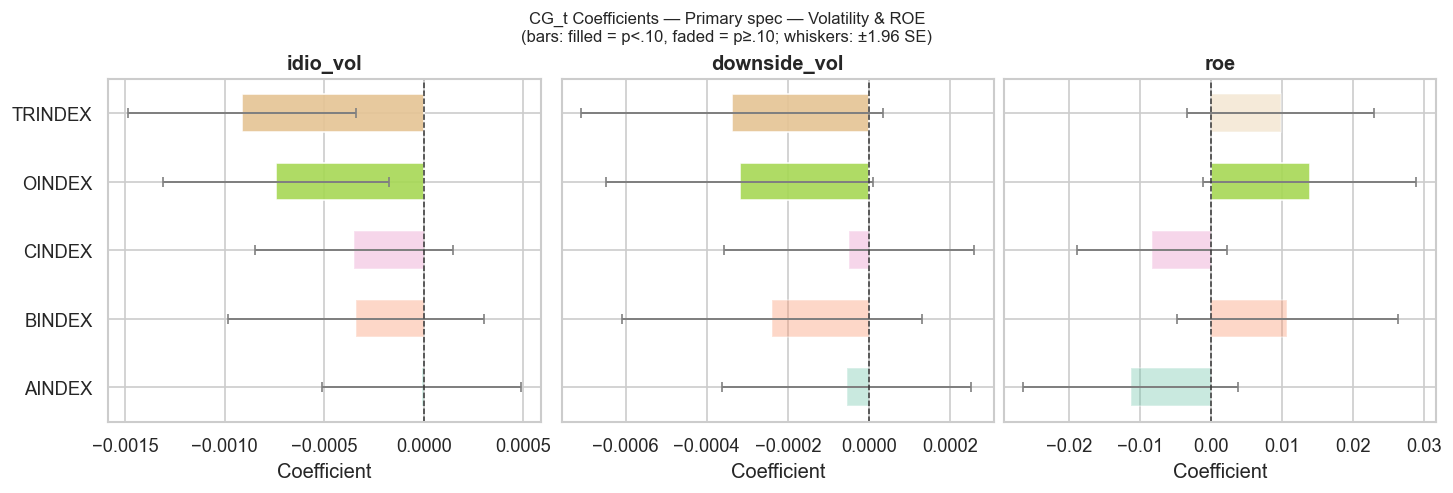

In [24]:
ind_run_primary = {}
for y_col in OUTCOMES:
    for cg in CG_CATS_PRIMARY:
        x_cols = [cg] + CTRL + fe_cols_primary
        res, diag = run_ols(model_df_primary, y_col, x_cols)
        ind_run_primary[(y_col, cg)] = (res, diag)

print_reg_table(ind_run_primary, OUTCOMES, CG_CATS_PRIMARY,
                title='PRIMARY SPEC: outcome_t+1 ~ CG_t + controls + industry/year FE (singleton industries dropped, DINDEX excluded)')
plot_coef_forest(ind_run_primary, OUTCOMES[:4], CG_CATS_PRIMARY, 'Primary spec — Returns & Alpha')
plot_coef_forest(ind_run_primary, OUTCOMES[4:], CG_CATS_PRIMARY, 'Primary spec — Volatility & ROE')

### 10.2 — Joint and composite regressions (primary spec)

In [25]:
joint_run_primary = {}
for y_col in OUTCOMES:
    x_cols = CG_CATS_PRIMARY + CTRL + fe_cols_primary
    res, diag = run_ols(model_df_primary, y_col, x_cols)
    joint_run_primary[y_col] = (res, diag)

print_joint_table(joint_run_primary, OUTCOMES, CG_CATS_PRIMARY, title='PRIMARY SPEC — Joint sub-index regression')

comp_run_primary = {}
for y_col in OUTCOMES:
    x_cols = ['COMPOSITE_5'] + CTRL + fe_cols_primary
    res, diag = run_ols(model_df_primary, y_col, x_cols)
    comp_run_primary[(y_col, 'COMPOSITE_5')] = (res, diag)

print_reg_table(comp_run_primary, OUTCOMES, ['COMPOSITE_5'], title='PRIMARY SPEC — Composite regression (5-index COMPOSITE_5)')


  PRIMARY SPEC — Joint sub-index regression  (joint model)
Variable          mar_pct            capm_alpha          ff5_alpha           total_vol            idio_vol          downside_vol            roe         
----------------------------------------------------------------------------------------------------------------------------------------------------------
AINDEX        +0.0254 (0.0199)    +0.0212 (0.0182)    -0.0446 (0.0274)    +0.0001 (0.0003)    -0.0000 (0.0003)    -0.0001 (0.0002)    -0.0125 (0.0078)  
BINDEX       +0.0417* (0.0237)    +0.0276 (0.0211)  +0.0835*** (0.0303)   -0.0004 (0.0003)   -0.0005* (0.0003)    -0.0003 (0.0002)    +0.0102 (0.0080)  
CINDEX        -0.0231 (0.0248)    -0.0215 (0.0233)    -0.0385 (0.0259)   -0.0006** (0.0003)  -0.0006** (0.0003)   -0.0002 (0.0002)    -0.0071 (0.0058)  
OINDEX        -0.0101 (0.0250)    -0.0085 (0.0232)    -0.0242 (0.0251)   -0.0006** (0.0003)  -0.0007** (0.0003)  -0.0003* (0.0002)   +0.0123* (0.0072)  
TRINDEX       -0.019


  PRIMARY SPEC — Composite regression (5-index COMPOSITE_5)
CG Index          mar_pct            capm_alpha          ff5_alpha           total_vol            idio_vol          downside_vol            roe         
                   β (SE)              β (SE)              β (SE)              β (SE)              β (SE)              β (SE)              β (SE)       
----------------------------------------------------------------------------------------------------------------------------------------------------------
COMPOSITE_5   +0.0032 (0.0225)    -0.0011 (0.0196)   +0.0424* (0.0250)  -0.0010*** (0.0003) -0.0010*** (0.0003) -0.0005*** (0.0002)   +0.0076 (0.0075)  
----------------------------------------------------------------------------------------------------------------------------------------------------------
N                   411                 411                 411                 411                 411                 411                 410         
R²               

### 10.3 — Romano-Wolf across the primary-spec family (5 CG cats x 7 outcomes = 35 tests)

Same cluster-bootstrap machinery as Table A (`build_hyp_data` / `romano_wolf_cluster`,
`B=2000`), just re-run on `model_df_primary` with `cats=CG_CATS_PRIMARY` — a smaller,
DINDEX-free, singleton-free family, not a re-selected one.

In [26]:
hyp_data_primary = build_hyp_data(model_df_primary, fe_cols_primary, cats=CG_CATS_PRIMARY)
print(f'Hypotheses estimable: {len(hyp_data_primary)} / 35')

t_rw_primary, p_rw_primary = romano_wolf_cluster(hyp_data_primary, B=RW_B)
rw_df_primary = pd.DataFrame({'t': t_rw_primary, 'p_rw': p_rw_primary}).reset_index()
rw_df_primary[['Category', 'Outcome']] = pd.DataFrame(rw_df_primary['index'].tolist(), index=rw_df_primary.index)
rw_df_primary = rw_df_primary.drop(columns='index')[['Category', 'Outcome', 't', 'p_rw']].sort_values('p_rw')
rw_df_primary['sig_rw'] = rw_df_primary['p_rw'].apply(sig_stars)

print(rw_df_primary.round(4).to_string(index=False))
print(f"\nSurvive RW p<.10: {(rw_df_primary['p_rw'] < 0.10).sum()} / {len(rw_df_primary)}")

Hypotheses estimable: 35 / 35


Category      Outcome       t   p_rw sig_rw
 TRINDEX     idio_vol -3.1228 0.1270       
 TRINDEX    total_vol -3.0387 0.1530       
  BINDEX    ff5_alpha  2.8563 0.2170       
  OINDEX     idio_vol -2.5532 0.3635       
  OINDEX    total_vol -2.1027 0.6770       
  CINDEX    ff5_alpha -2.0067 0.7370       
  OINDEX downside_vol -1.8966 0.8030       
  BINDEX      mar_pct  1.8668 0.8030       
  OINDEX          roe  1.8076 0.8405       
 TRINDEX downside_vol -1.7825 0.8460       
  CINDEX          roe -1.5335 0.9350       
  AINDEX      mar_pct  1.2857 0.9425       
 TRINDEX    ff5_alpha  1.2970 0.9425       
  CINDEX     idio_vol -1.3738 0.9425       
  CINDEX    total_vol -1.4687 0.9425       
  BINDEX   capm_alpha  1.4290 0.9425       
  AINDEX   capm_alpha  1.1617 0.9425       
  AINDEX    ff5_alpha -1.2248 0.9425       
  AINDEX          roe -1.4645 0.9425       
 TRINDEX          roe  1.4545 0.9425       
  BINDEX downside_vol -1.2683 0.9425       
  BINDEX          roe  1.3603 0.

### 10.4 — Robustness: Sector FE (full 236-firm panel, no singleton drop needed)

11 sectors, 4-42 firms each, zero singletons — every firm from Table A is retained here.
Reported as a robustness check, not the headline, per the framing decision above.

In [27]:
sec_firm_counts = panel.groupby('Sector')['BSE Code'].nunique()
print(f'Sectors: {sec_firm_counts.shape[0]}, min firms/sector={sec_firm_counts.min()}, '
      f'singleton sectors={(sec_firm_counts == 1).sum()}')

def build_model_df_sector(base_df):
    df = base_df.copy()
    df = pd.concat([df, fe_dummies(df, 'Sector', 'SEC'), fe_dummies(df, 'FY', 'FY')], axis=1)
    return df

model_df_sectorfe = build_model_df_sector(panel)
fe_cols_sectorfe = [c for c in model_df_sectorfe.columns if c.startswith('_FE_')]
print(f'FE dummies: {len(fe_cols_sectorfe)}')

ind_run_sectorfe = {}
for y_col in OUTCOMES:
    for cg in CG_CATS_PRIMARY:
        x_cols = [cg] + CTRL + fe_cols_sectorfe
        res, diag = run_ols(model_df_sectorfe, y_col, x_cols)
        ind_run_sectorfe[(y_col, cg)] = (res, diag)

hyp_data_sectorfe = build_hyp_data(model_df_sectorfe, fe_cols_sectorfe, cats=CG_CATS_PRIMARY)
t_rw_sec, p_rw_sec = romano_wolf_cluster(hyp_data_sectorfe, B=RW_B)
rw_df_sectorfe = pd.DataFrame({'t': t_rw_sec, 'p_rw': p_rw_sec}).reset_index()
rw_df_sectorfe[['Category', 'Outcome']] = pd.DataFrame(rw_df_sectorfe['index'].tolist(), index=rw_df_sectorfe.index)
rw_df_sectorfe = rw_df_sectorfe.drop(columns='index')[['Category', 'Outcome', 't', 'p_rw']].sort_values('p_rw')
rw_df_sectorfe['sig_rw'] = rw_df_sectorfe['p_rw'].apply(sig_stars)

print(rw_df_sectorfe.round(4).to_string(index=False))
print(f"\n[Sector-FE robustness] Survive RW p<.10: {(rw_df_sectorfe['p_rw'] < 0.10).sum()} / {len(rw_df_sectorfe)}")

Sectors: 11, min firms/sector=4, singleton sectors=0
FE dummies: 11


Category      Outcome       t   p_rw sig_rw
 TRINDEX    total_vol -4.1120 0.0050    ***
 TRINDEX     idio_vol -3.7577 0.0130     **
  BINDEX    ff5_alpha  3.2664 0.0500      *
 TRINDEX      mar_pct -2.8793 0.1310       
 TRINDEX   capm_alpha -2.4697 0.3355       
  OINDEX     idio_vol -2.3140 0.4465       
 TRINDEX          roe  2.2725 0.4720       
  BINDEX          roe  2.0822 0.6160       
  OINDEX    total_vol -1.8927 0.7310       
  AINDEX          roe -1.7033 0.8485       
  BINDEX      mar_pct  1.3826 0.9635       
 TRINDEX downside_vol -1.3546 0.9675       
  OINDEX      mar_pct -1.3147 0.9685       
  CINDEX    ff5_alpha -1.2247 0.9785       
  CINDEX    total_vol -1.1864 0.9830       
  AINDEX downside_vol -1.1856 0.9830       
  OINDEX   capm_alpha -1.1385 0.9895       
  CINDEX     idio_vol -1.0065 0.9930       
  OINDEX          roe  1.0275 0.9930       
  AINDEX      mar_pct  0.7296 0.9965       
  AINDEX   capm_alpha  0.7152 0.9965       
  AINDEX    ff5_alpha -0.9034 0.

### 10.5 — Save outputs

Distinct filenames — none of Table A/B/C's saved artifacts are overwritten.

In [28]:
panel_primary.to_csv(PROC / 'panel_regression_ready_primary.csv', index=False)
rw_df_primary.to_csv(PROC / 'panel_romano_wolf_primary.csv', index=False)
rw_df_sectorfe.to_csv(PROC / 'panel_romano_wolf_primary_sectorfe.csv', index=False)

ind_rows_primary = []
for (y_col, cg), (res, diag) in ind_run_primary.items():
    if res is None: continue
    rw_row = rw_df_primary[(rw_df_primary['Category'] == cg) & (rw_df_primary['Outcome'] == y_col)]
    ind_rows_primary.append({'Outcome': y_col, 'Category': cg, 'N': diag['N'],
                             'beta': res.params.get(cg, np.nan), 'se': res.bse.get(cg, np.nan),
                             't': res.tvalues.get(cg, np.nan), 'p_raw': res.pvalues.get(cg, np.nan),
                             'p_rw': rw_row['p_rw'].iloc[0] if len(rw_row) else np.nan})
ind_summary_primary_df = pd.DataFrame(ind_rows_primary)
ind_summary_primary_df.to_csv(PROC / 'panel_individual_regressions_primary.csv', index=False)

print('Saved:')
for f in ['panel_regression_ready_primary.csv', 'panel_romano_wolf_primary.csv',
          'panel_romano_wolf_primary_sectorfe.csv', 'panel_individual_regressions_primary.csv']:
    print(f'  -> data/processed/{f}')

print('\n' + '=' * 68)
print('  SECTION 10 — CORRECTED PRIMARY SPEC SUMMARY')
print('=' * 68)
print(f'Primary spec  : N={len(panel_primary)}, {panel_primary["BSE Code"].nunique()} firms '
      f'(vs Table A: N={len(panel)}, {panel["BSE Code"].nunique()} firms)')
print(f'CG_CATS_PRIMARY: {CG_CATS_PRIMARY}  (DINDEX excluded)')
print(f"Primary-spec RW survivors (p<.10)  : {(rw_df_primary['p_rw'] < 0.10).sum()} / {len(rw_df_primary)}")
print(f"Sector-FE robustness RW survivors  : {(rw_df_sectorfe['p_rw'] < 0.10).sum()} / {len(rw_df_sectorfe)}")
sig_primary = rw_df_primary[rw_df_primary['p_rw'] < 0.10]
sig_sectorfe = rw_df_sectorfe[rw_df_sectorfe['p_rw'] < 0.10]
if len(sig_primary):
    print('\nPrimary-spec survivors:')
    print(sig_primary.round(4).to_string(index=False))
if len(sig_sectorfe):
    print('\nSector-FE robustness survivors (NOT the headline spec):')
    print(sig_sectorfe.round(4).to_string(index=False))
print('=' * 68)

Saved:
  -> data/processed/panel_regression_ready_primary.csv
  -> data/processed/panel_romano_wolf_primary.csv
  -> data/processed/panel_romano_wolf_primary_sectorfe.csv
  -> data/processed/panel_individual_regressions_primary.csv

  SECTION 10 — CORRECTED PRIMARY SPEC SUMMARY
Primary spec  : N=418, 209 firms (vs Table A: N=468, 234 firms)
CG_CATS_PRIMARY: ['AINDEX', 'BINDEX', 'CINDEX', 'OINDEX', 'TRINDEX']  (DINDEX excluded)
Primary-spec RW survivors (p<.10)  : 0 / 35
Sector-FE robustness RW survivors  : 3 / 35

Sector-FE robustness survivors (NOT the headline spec):
Category   Outcome       t   p_rw sig_rw
 TRINDEX total_vol -4.1120 0.0050    ***
 TRINDEX  idio_vol -3.7577 0.0130     **
  BINDEX ff5_alpha  3.2664 0.0500      *


## 11 — Robustness: AR/Reg30-augmented indices

`14_index_extension.ipynb` extended AINDEX/BINDEX/CINDEX with 6 new metrics agreed with
the user (audit fees, auditor changes -> AINDEX; director changes -> BINDEX; rating
downgrades, RPT value, promoter pledge -> CINDEX), saved to
`cg_scores_augmented_fy.csv`. This section substitutes those augmented indices for the
original AINDEX/BINDEX/CINDEX in the **Section 10 primary spec** (same 210-firm,
singleton-industry-dropped panel, same controls/FE/outcomes, DINDEX still excluded) and
re-runs the identical machinery — a robustness check, decided in advance, not a re-spec
chosen after seeing results.

The augmented scores are VdW-transformed per FY cross-section, identical convention to
every other `CG_t` regressor in this notebook (Section 2).

In [29]:
aug = pd.read_csv(PROC / 'cg_scores_augmented_fy.csv')
aug['BSE Code'] = pd.to_numeric(aug['BSE Code'], errors='coerce')
aug = aug[aug['FY'].isin(FYS)][['BSE Code', 'FY', 'AINDEX_augmented', 'BINDEX_augmented', 'CINDEX_augmented']]

for col in ['AINDEX_augmented', 'BINDEX_augmented', 'CINDEX_augmented']:
    aug[col] = aug.groupby('FY')[col].transform(vdw_score)

panel_aug = panel_primary.merge(aug, on=['BSE Code', 'FY'], how='left')
print(f'Augmented-spec panel: N={len(panel_aug)} (same base as Section 10\'s primary spec)')
for c in ['AINDEX_augmented', 'BINDEX_augmented', 'CINDEX_augmented']:
    print(f'  {c}: {panel_aug[c].notna().sum()} / {len(panel_aug)} non-null')

CG_CATS_AUG = ['AINDEX_augmented', 'BINDEX_augmented', 'CINDEX_augmented', 'OINDEX', 'TRINDEX']
model_df_aug = build_model_df(panel_aug)
fe_cols_aug = [c for c in model_df_aug.columns if c.startswith('_FE_')]

Augmented-spec panel: N=418 (same base as Section 10's primary spec)
  AINDEX_augmented: 415 / 418 non-null
  BINDEX_augmented: 411 / 418 non-null
  CINDEX_augmented: 418 / 418 non-null


### 11.1 — Individual sub-index regressions (augmented spec)

In [30]:
ind_run_aug = {}
for y_col in OUTCOMES:
    for cg in CG_CATS_AUG:
        x_cols = [cg] + CTRL + fe_cols_aug
        res, diag = run_ols(model_df_aug, y_col, x_cols)
        ind_run_aug[(y_col, cg)] = (res, diag)

print_reg_table(ind_run_aug, OUTCOMES, CG_CATS_AUG,
                title='AUGMENTED SPEC: outcome_t+1 ~ CG_t (AR/Reg30-augmented) + controls + industry/year FE')


  AUGMENTED SPEC: outcome_t+1 ~ CG_t (AR/Reg30-augmented) + controls + industry/year FE
CG Index          mar_pct            capm_alpha          ff5_alpha           total_vol            idio_vol          downside_vol            roe         
                   β (SE)              β (SE)              β (SE)              β (SE)              β (SE)              β (SE)              β (SE)       
----------------------------------------------------------------------------------------------------------------------------------------------------------
AINDEX_augmented  -0.0133 (0.0220)    -0.0172 (0.0200)   -0.0613** (0.0293)   -0.0002 (0.0003)    -0.0002 (0.0003)    -0.0002 (0.0002)    -0.0014 (0.0044)  
BINDEX_augmented  +0.0119 (0.0251)    +0.0092 (0.0234)   +0.0538* (0.0285)    -0.0002 (0.0003)    -0.0002 (0.0003)    -0.0001 (0.0001)    +0.0084 (0.0065)  
CINDEX_augmented  -0.0064 (0.0187)    -0.0003 (0.0176)    -0.0308 (0.0267)    -0.0001 (0.0002)    -0.0000 (0.0002)    -0.0000 (0.0002)  

### 11.2 — Romano-Wolf across the augmented-spec family (5 cats x 7 outcomes = 35 tests)

Same `build_hyp_data` / `romano_wolf_cluster` machinery, `B=RW_B` (2000), just re-run on
`model_df_aug` with `cats=CG_CATS_AUG`.

In [31]:
hyp_data_aug = build_hyp_data(model_df_aug, fe_cols_aug, cats=CG_CATS_AUG)
print(f'Hypotheses estimable: {len(hyp_data_aug)} / 35')

t_rw_aug, p_rw_aug = romano_wolf_cluster(hyp_data_aug, B=RW_B)
rw_df_aug = pd.DataFrame({'t': t_rw_aug, 'p_rw': p_rw_aug}).reset_index()
rw_df_aug[['Category', 'Outcome']] = pd.DataFrame(rw_df_aug['index'].tolist(), index=rw_df_aug.index)
rw_df_aug = rw_df_aug.drop(columns='index')[['Category', 'Outcome', 't', 'p_rw']].sort_values('p_rw')
rw_df_aug['sig_rw'] = rw_df_aug['p_rw'].apply(sig_stars)

print(rw_df_aug.round(4).to_string(index=False))
print(f"\nSurvive RW p<.10: {(rw_df_aug['p_rw'] < 0.10).sum()} / {len(rw_df_aug)}")
print(f"(vs Section 10 primary spec: {(rw_df_primary['p_rw'] < 0.10).sum()} / {len(rw_df_primary)})")

Hypotheses estimable: 35 / 35


        Category      Outcome       t   p_rw sig_rw
         TRINDEX     idio_vol -3.1228 0.1125       
         TRINDEX    total_vol -3.0387 0.1340       
          OINDEX     idio_vol -2.5532 0.3515       
AINDEX_augmented    ff5_alpha -2.0962 0.6860       
          OINDEX    total_vol -2.1027 0.6860       
BINDEX_augmented    ff5_alpha  1.8917 0.8230       
          OINDEX downside_vol -1.8966 0.8230       
          OINDEX          roe  1.8076 0.8360       
         TRINDEX downside_vol -1.7825 0.8405       
AINDEX_augmented downside_vol -1.6354 0.8920       
         TRINDEX          roe  1.4545 0.9535       
         TRINDEX    ff5_alpha  1.2970 0.9795       
BINDEX_augmented          roe  1.2976 0.9795       
CINDEX_augmented    ff5_alpha -1.1553 0.9885       
AINDEX_augmented     idio_vol -0.8953 0.9975       
AINDEX_augmented   capm_alpha -0.8584 0.9985       
         TRINDEX   capm_alpha -0.7875 0.9990       
          OINDEX    ff5_alpha -0.7569 0.9990       
AINDEX_augme

### 11.3 — Save outputs

Distinct filenames -- Section 10's primary-spec outputs are not overwritten.

In [32]:
panel_aug.to_csv(PROC / 'panel_regression_ready_augmented.csv', index=False)
rw_df_aug.to_csv(PROC / 'panel_romano_wolf_augmented.csv', index=False)

ind_rows_aug = []
for (y_col, cg), (res, diag) in ind_run_aug.items():
    if res is None: continue
    rw_row = rw_df_aug[(rw_df_aug['Category'] == cg) & (rw_df_aug['Outcome'] == y_col)]
    ind_rows_aug.append({'Outcome': y_col, 'Category': cg, 'N': diag['N'],
                         'beta': res.params.get(cg, np.nan), 'se': res.bse.get(cg, np.nan),
                         't': res.tvalues.get(cg, np.nan), 'p_raw': res.pvalues.get(cg, np.nan),
                         'p_rw': rw_row['p_rw'].iloc[0] if len(rw_row) else np.nan})
ind_summary_aug_df = pd.DataFrame(ind_rows_aug)
ind_summary_aug_df.to_csv(PROC / 'panel_individual_regressions_augmented.csv', index=False)

print('Saved:')
for f in ['panel_regression_ready_augmented.csv', 'panel_romano_wolf_augmented.csv',
          'panel_individual_regressions_augmented.csv']:
    print(f'  -> data/processed/{f}')

print('\n' + '=' * 68)
print('  SECTION 11 SUMMARY -- AR/REG30-AUGMENTED SPEC (ROBUSTNESS)')
print('=' * 68)
print(f"Augmented-spec RW survivors (p<.10): {(rw_df_aug['p_rw'] < 0.10).sum()} / {len(rw_df_aug)}")
print(f"Section 10 primary-spec RW survivors: {(rw_df_primary['p_rw'] < 0.10).sum()} / {len(rw_df_primary)}")
sig_aug = rw_df_aug[rw_df_aug['p_rw'] < 0.10]
if len(sig_aug):
    print('\nAugmented-spec survivors:')
    print(sig_aug.round(4).to_string(index=False))
else:
    print('\n(no survivors -- augmented spec is also a clean null)')
print('=' * 68)

Saved:
  -> data/processed/panel_regression_ready_augmented.csv
  -> data/processed/panel_romano_wolf_augmented.csv
  -> data/processed/panel_individual_regressions_augmented.csv

  SECTION 11 SUMMARY -- AR/REG30-AUGMENTED SPEC (ROBUSTNESS)
Augmented-spec RW survivors (p<.10): 0 / 35
Section 10 primary-spec RW survivors: 0 / 35

(no survivors -- augmented spec is also a clean null)


## 12 — Robustness: expanded controls (liquidity, profitability, investment)

Two control gaps identified: no liquidity control (illiquid stocks show mechanically
different vol/return patterns regardless of governance), and no firm-level
profitability/investment characteristics (the firm-characteristic analogs of FF5's
RMW/CMA factors — those factors are only netted out at the factor-regression level for
`ff5_alpha`, not controlled for as firm characteristics for the other 6 outcomes).

**New controls, real live-fetched data (`fetch_liquidity_profitability.py`, standalone
script, not part of this notebook):**
- `Amihud_Illiquidity` — mean(|daily return| / daily ₹ volume) over the trailing
  252-trading-day window ending each quarter-end (same window convention as
  `Beta_Market`), scaled by 1e6 for readability. Higher = less liquid.
- `ROA` — Net Income / Total Assets, nearest fiscal-year-end financials.
- `Asset_Growth` — (Total Assets_t − Total Assets_{t-1}) / Total Assets_{t-1} — needs
  **two consecutive years** of Total Assets, so its own coverage is lower than the other
  controls' (49% vs 92-96%) — this is the single biggest driver of the sample-size drop
  in this section, not new missingness in the CG/outcome variables themselves.

Same primary spec as Section 10 (DINDEX excluded, singleton industries dropped) — this
section only adds 3 more columns to `CTRL`, nothing else changes.

In [33]:
new_ctrl = pd.read_csv(PROC / 'controls_liquidity_profitability.csv')
new_ctrl['BSE Code'] = pd.to_numeric(new_ctrl['BSE Code'], errors='coerce')
new_ctrl['FY'] = new_ctrl['FY'].replace({'Q4FY23': 'FY23', 'Q4FY24': 'FY24'})
new_ctrl_fy = new_ctrl.groupby(['BSE Code', 'FY'])[['ROA', 'Asset_Growth', 'Amihud_Illiquidity']].first().reset_index()

CTRL_NEW = ['Amihud_Illiquidity', 'ROA', 'Asset_Growth']
CTRL_EXPANDED = CTRL + CTRL_NEW

panel_expctrl = panel_primary.merge(new_ctrl_fy, on=['BSE Code', 'FY'], how='left')
print(f'Panel: N={len(panel_expctrl)}')
for c in CTRL_NEW:
    print(f'  {c}: {panel_expctrl[c].notna().sum()} / {len(panel_expctrl)} non-null '
          f'({panel_expctrl[c].notna().mean():.1%})')

for c in CTRL_NEW:
    panel_expctrl[c] = winsorize(panel_expctrl[c])

model_df_expctrl = build_model_df(panel_expctrl)
fe_cols_expctrl = [c for c in model_df_expctrl.columns if c.startswith('_FE_')]

Panel: N=418
  Amihud_Illiquidity: 404 / 418 non-null (96.7%)
  ROA: 402 / 418 non-null (96.2%)
  Asset_Growth: 204 / 418 non-null (48.8%)


### 12.1 — Individual sub-index regressions (expanded controls)

In [34]:
ind_run_expctrl = {}
for y_col in OUTCOMES:
    for cg in CG_CATS_PRIMARY:
        x_cols = [cg] + CTRL_EXPANDED + fe_cols_expctrl
        res, diag = run_ols(model_df_expctrl, y_col, x_cols)
        ind_run_expctrl[(y_col, cg)] = (res, diag)

print_reg_table(ind_run_expctrl, OUTCOMES, CG_CATS_PRIMARY,
                title='EXPANDED-CONTROLS SPEC: + Amihud_Illiquidity, ROA, Asset_Growth')
print(f'\nN range in this spec: '
      f'{min(d["N"] for _,d in ind_run_expctrl.values() if d) if any(ind_run_expctrl.values()) else "n/a"}'
      f'-{max(d["N"] for _,d in ind_run_expctrl.values() if d) if any(ind_run_expctrl.values()) else "n/a"} '
      f'(vs Section 10\'s 395-413 -- Asset_Growth\'s 49% coverage is the binding constraint)')


  EXPANDED-CONTROLS SPEC: + Amihud_Illiquidity, ROA, Asset_Growth
CG Index          mar_pct            capm_alpha          ff5_alpha           total_vol            idio_vol          downside_vol            roe         
                   β (SE)              β (SE)              β (SE)              β (SE)              β (SE)              β (SE)              β (SE)       
----------------------------------------------------------------------------------------------------------------------------------------------------------
AINDEX        -0.0275 (0.0243)    -0.0294 (0.0245)   -0.1124* (0.0571)    +0.0001 (0.0003)    +0.0001 (0.0003)    +0.0001 (0.0002)    -0.0005 (0.0086)  
BINDEX        -0.0135 (0.0226)    -0.0136 (0.0228)   +0.1138** (0.0484)   -0.0005 (0.0004)   -0.0007* (0.0004)    -0.0004 (0.0003)    -0.0070 (0.0083)  
CINDEX        +0.0112 (0.0214)    +0.0107 (0.0216)    -0.0262 (0.0561)   -0.0006** (0.0003)  -0.0005* (0.0003)    -0.0004 (0.0002)    -0.0005 (0.0050)  
OINDEX       

### 12.2 — Romano-Wolf across the expanded-controls family (35 tests)

In [35]:
hyp_data_expctrl = build_hyp_data(model_df_expctrl, fe_cols_expctrl, cats=CG_CATS_PRIMARY, controls=CTRL_EXPANDED)
print(f'Hypotheses estimable: {len(hyp_data_expctrl)} / 35')

t_rw_expctrl, p_rw_expctrl = romano_wolf_cluster(hyp_data_expctrl, B=RW_B)
rw_df_expctrl = pd.DataFrame({'t': t_rw_expctrl, 'p_rw': p_rw_expctrl}).reset_index()
rw_df_expctrl[['Category', 'Outcome']] = pd.DataFrame(rw_df_expctrl['index'].tolist(), index=rw_df_expctrl.index)
rw_df_expctrl = rw_df_expctrl.drop(columns='index')[['Category', 'Outcome', 't', 'p_rw']].sort_values('p_rw')
rw_df_expctrl['sig_rw'] = rw_df_expctrl['p_rw'].apply(sig_stars)

print(rw_df_expctrl.round(4).to_string(index=False))
print(f"\nSurvive RW p<.10: {(rw_df_expctrl['p_rw'] < 0.10).sum()} / {len(rw_df_expctrl)}")
print(f"(vs Section 10 primary spec: {(rw_df_primary['p_rw'] < 0.10).sum()} / {len(rw_df_primary)})")

Hypotheses estimable: 35 / 35


Category      Outcome       t   p_rw sig_rw
 TRINDEX    total_vol -2.5879 0.3465       
 TRINDEX     idio_vol -2.3705 0.4890       
  BINDEX    ff5_alpha  2.3529 0.4945       
  OINDEX   capm_alpha  2.1527 0.6445       
  OINDEX      mar_pct  2.0776 0.6980       
  CINDEX    total_vol -1.9775 0.7365       
  AINDEX    ff5_alpha -1.9679 0.7380       
  BINDEX     idio_vol -1.7476 0.8650       
  CINDEX     idio_vol -1.7369 0.8695       
  CINDEX downside_vol -1.4706 0.9640       
  BINDEX    total_vol -1.4119 0.9705       
  BINDEX downside_vol -1.3319 0.9785       
  AINDEX   capm_alpha -1.1995 0.9830       
 TRINDEX    ff5_alpha  1.2391 0.9830       
  OINDEX    ff5_alpha -1.2179 0.9830       
  AINDEX      mar_pct -1.1300 0.9855       
 TRINDEX downside_vol -1.0091 0.9950       
  BINDEX          roe -0.8434 0.9980       
  CINDEX    ff5_alpha -0.4680 1.0000       
  AINDEX    total_vol  0.3876 1.0000       
  AINDEX     idio_vol  0.2064 1.0000       
  AINDEX downside_vol  0.4320 1.

### 12.3 — Save outputs

In [36]:
panel_expctrl.to_csv(PROC / 'panel_regression_ready_expanded_controls.csv', index=False)
rw_df_expctrl.to_csv(PROC / 'panel_romano_wolf_expanded_controls.csv', index=False)

print('Saved:')
for f in ['panel_regression_ready_expanded_controls.csv', 'panel_romano_wolf_expanded_controls.csv']:
    print(f'  -> data/processed/{f}')

print('\n' + '=' * 68)
print('  SECTION 12 SUMMARY -- EXPANDED-CONTROLS SPEC (ROBUSTNESS)')
print('=' * 68)
print(f"Expanded-controls RW survivors (p<.10): {(rw_df_expctrl['p_rw'] < 0.10).sum()} / {len(rw_df_expctrl)}")
print(f"Section 10 primary-spec RW survivors  : {(rw_df_primary['p_rw'] < 0.10).sum()} / {len(rw_df_primary)}")
sig = rw_df_expctrl[rw_df_expctrl['p_rw'] < 0.10]
print('\n(no survivors)' if not len(sig) else sig.round(4).to_string(index=False))
print('=' * 68)

Saved:
  -> data/processed/panel_regression_ready_expanded_controls.csv
  -> data/processed/panel_romano_wolf_expanded_controls.csv

  SECTION 12 SUMMARY -- EXPANDED-CONTROLS SPEC (ROBUSTNESS)
Expanded-controls RW survivors (p<.10): 0 / 35
Section 10 primary-spec RW survivors  : 0 / 35

(no survivors)
